# Riesgo y predicción cuantitativa: factores asociados al mal riesgo crediticio
## Statlog German Credit Data (UCI)

**Curso:** MCC002 - Probabilidad y Estadística Computacional  
**Periodo académico:** 2026-1  
**Programa:** Maestría en Ciencia de la Computación - FC, UNI  
**Docente:** Dra. Rocío Milagros Zorrilla Coz  
**Grupo N.º 5:** Armando Castro Chaupis - Henry Sánchez Alvarado - Alex Segura Núñez  

---

**Pregunta de investigación central:** |¿Qué factores explican la probabilidad de que un solicitante sea clasificado como *mal riesgo crediticio*?

**Preguntas secundarias (consigna del Grupo 5):**

1. Proporción global de malos créditos y su IC 95 %.
2. ¿La tasa de mal crédito difiere según el propósito del préstamo?
3. ¿La duración y el monto del crédito difieren entre buenos y malos créditos?
4. ¿Qué variables están asociadas con mayor riesgo crediticio?
5. ¿Cómo cambia la clasificación al modificar el umbral de decisión?

---

El análisis integra estadística descriptiva, inferencia frecuentista, regresión, evaluación predictiva y métodos bayesianos. Cada bloque sigue la secuencia:

**Problema real → Marco teórico → Solución computacional → Evaluación crítica.**

## 1. Introducción al problema y enfoque del análisis

La evaluación del riesgo crediticio es un problema de decisión bajo incertidumbre. Antes de otorgar un préstamo, una entidad financiera debe estimar si el solicitante cumplirá con las condiciones de pago. Esta decisión puede producir dos tipos de error: aprobar a un cliente que posteriormente incumple o rechazar a uno que habría pagado correctamente. Ambos errores generan consecuencias distintas y, por tanto, no deben tratarse como si tuvieran el mismo costo.

El conjunto de datos *Statlog German Credit* representa esta asimetría mediante una matriz de costos 5:1. Clasificar un mal crédito como bueno tiene un costo cinco veces mayor que clasificar un buen crédito como malo. Esta estructura se incorporará posteriormente al análisis de los umbrales de decisión.

La variable objetivo se define como:

$$
Y_i=
\begin{cases}
0, & \text{si el crédito corresponde a un buen riesgo},\\
1, & \text{si el crédito corresponde a un mal riesgo}.
\end{cases}
$$

Bajo esta codificación, cada observación puede modelarse inicialmente como una variable Bernoulli. La probabilidad de mal riesgo se representa mediante:

$$
Y_i \mid p_i \sim \operatorname{Bernoulli}(p_i),
$$

donde $p_i$ puede referirse a la proporción global de malos créditos o depender de las características del solicitante y del préstamo.

El análisis combina tres enfoques. Primero, se emplean métodos frecuentistas para estimar la proporción global de malos créditos y evaluar diferencias entre grupos. Segundo, se ajusta una regresión logística para estudiar la asociación entre las covariables y la probabilidad condicional de mal riesgo:

$$
\Pr(Y_i=1\mid\mathbf{x}_i)
=
\frac{\exp(\mathbf{x}_i^\top\boldsymbol{\beta})}
{1+\exp(\mathbf{x}_i^\top\boldsymbol{\beta})}.
$$

Los coeficientes del modelo se interpretarán mediante *odds ratios*, considerando simultáneamente las demás variables incluidas. Debido al carácter observacional de los datos, los resultados se entenderán como asociaciones y no como efectos causales.

Tercero, se desarrolla un análisis bayesiano de la proporción global de malos créditos mediante un modelo Beta-Binomial. Como extensión computacional, se implementa un algoritmo Metropolis–Hastings para aproximar la distribución posterior de un coeficiente del modelo logístico.

La evaluación predictiva no se basará únicamente en el *accuracy*. Dado que el 70 % de las observaciones corresponde a buenos créditos, un clasificador que asignara todos los casos a esta categoría alcanzaría un *accuracy* de 70 %, pero no identificaría ningún mal crédito. Por esta razón, el desempeño se evaluará mediante ROC–AUC, *precision*, *recall*, matrices de confusión y el costo ponderado de clasificación:

$$
C=5FN+FP,
$$

donde $FN$ representa los malos créditos clasificados como buenos y $FP$ los buenos créditos clasificados como malos.

## 2. Configuración del entorno y reproducibilidad

Entorno: Python ≥ 3.10 con `numpy`, `scipy`, `pandas`, `matplotlib`, `seaborn`, `statsmodels` y `scikit-learn`.
Se fija la semilla global al inicio (`numpy.random.seed`) y se registran las versiones de las librerías. El archivo `requirements.txt` acompaña al entregable.

In [1]:
# --- Librerías y configuración global ---
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint
import sklearn


from pathlib import Path
import io
import zipfile
import urllib.request


# Reproducibilidad: semilla global fijada al inicio
SEED = 2026
np.random.seed(SEED)

# Estilo de gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

print("Python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scipy       :", scipy.__version__)
print("statsmodels :", sm.__version__ if hasattr(sm, "__version__") else "ver requirements.txt")
print("scikit-learn:", sklearn.__version__)
print("seaborn     :", sns.__version__)

Python      : 3.12.10
numpy       : 2.4.6
pandas      : 3.0.3
scipy       : 1.17.1
statsmodels : 0.14.6
scikit-learn: 1.9.0
seaborn     : 0.13.2


## 3. Descripción, citación y carga del dataset

**Dataset principal:** *Statlog (German Credit Data)* — UCI Machine Learning Repository.

> Hofmann, H. (1994). *Statlog (German Credit Data)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5NC77
> URL: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data · Licencia: CC BY 4.0.

- **1000 observaciones** (solicitantes de crédito de un banco alemán) y **20 atributos predictores** (7 numéricos, 13 categóricos codificados como `Axy`), más la clase de riesgo (`1 = bueno`, `2 = malo`).
- El archivo original `german.data` está separado por espacios y **no tiene cabecera**; los nombres y significados de los atributos provienen del archivo de documentación oficial `german.doc`.
- El dataset **exige el uso de una matriz de costos**: clasificar un cliente *malo* como *bueno* cuesta **5**, y clasificar un *bueno* como *malo* cuesta **1**.

La celda siguiente intenta cargar el archivo local `data/german.data` (o `german.data` en el directorio del notebook); si no existe, lo descarga de la URL oficial de UCI y lo guarda en `data/` para dejar la descarga documentada y reproducible.

In [2]:
# CONFIGURACIÓN DE RUTAS

UCI_ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/144/"
    "statlog+german+credit+data.zip"
)


def encontrar_raiz_proyecto(inicio: Path | None = None) -> Path:
    """
    Busca la raíz del repositorio desde el directorio actual.

    Se considera raíz del proyecto al primer directorio que contenga
    la carpeta .git o el archivo README.md.
    """
    inicio = (inicio or Path.cwd()).resolve()

    for ruta in (inicio, *inicio.parents):
        if (ruta / ".git").exists() or (ruta / "README.md").exists():
            return ruta

    # Respaldo para ejecuciones fuera del repositorio
    return inicio


raiz_proyecto = encontrar_raiz_proyecto()
DIRECTORIO_DATOS = raiz_proyecto / "data"
RUTA_DATOS = DIRECTORIO_DATOS / "german.data"


# NOMBRES DE LAS VARIABLES

columnas = [
    "estado_cuenta",
    "duracion",
    "historial_credito",
    "proposito",
    "monto",
    "ahorros",
    "empleo_actual",
    "tasa_cuota",
    "estatus_personal_sexo",
    "otros_deudores",
    "anios_residencia",
    "propiedad",
    "edad",
    "otros_planes_pago",
    "vivienda",
    "n_creditos_banco",
    "trabajo",
    "n_dependientes",
    "telefono",
    "trabajador_extranjero",
    "clase",
]


# CARGA DEL DATASET

if not RUTA_DATOS.exists():
    print("No se encontró la copia local. Descargando desde UCI...")

    DIRECTORIO_DATOS.mkdir(parents=True, exist_ok=True)

    try:
        with urllib.request.urlopen(UCI_ZIP_URL, timeout=30) as respuesta:
            contenido_zip = respuesta.read()

        with zipfile.ZipFile(io.BytesIO(contenido_zip)) as archivo_zip:
            if "german.data" not in archivo_zip.namelist():
                raise FileNotFoundError(
                    "El archivo german.data no se encontró dentro del ZIP."
                )

            archivo_zip.extract("german.data", path=DIRECTORIO_DATOS)

    except Exception as error:
        raise RuntimeError(
            "No fue posible encontrar el dataset local ni descargarlo "
            "desde UCI. Verifique que exista data/german.data."
        ) from error


df = pd.read_csv(
    RUTA_DATOS,
    sep=r"\s+",
    header=None,
    names=columnas,
)


# VALIDACIONES BÁSICAS

if df.shape != (1000, 21):
    raise ValueError(
        "Las dimensiones del dataset no coinciden con la documentación. "
        f"Se esperaba (1000, 21) y se obtuvo {df.shape}."
    )

if not df["clase"].isin([1, 2]).all():
    raise ValueError(
        "La variable clase contiene valores distintos de 1 y 2."
    )


print(f"Raíz del proyecto: {raiz_proyecto}")
print(f"Archivo cargado: {RUTA_DATOS.relative_to(raiz_proyecto)}")
print(
    f"Dimensiones: {df.shape[0]} observaciones "
    f"× {df.shape[1]} columnas"
)

df.head()

Raíz del proyecto: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final
Archivo cargado: data\german.data
Dimensiones: 1000 observaciones × 21 columnas


,estado_cuenta,duracion,historial_credito,proposito,monto,ahorros,empleo_actual,tasa_cuota,estatus_personal_sexo,otros_deudores,...,propiedad,edad,otros_planes_pago,vivienda,n_creditos_banco,trabajo,n_dependientes,telefono,trabajador_extranjero,clase
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### 3.1 Diccionario de variables

El conjunto de datos contiene 20 variables predictoras y una variable de clasificación. De acuerdo con la documentación original `german.doc`, trece predictores son cualitativos y utilizan códigos de la forma `Axy`, mientras que siete se encuentran registrados mediante valores numéricos.

En este análisis se conserva la codificación original del conjunto *Statlog German Credit*. Las etiquetas en español se utilizarán únicamente para facilitar la lectura de tablas y gráficos, sin modificar los valores originales.

| # | Variable | Tipo | Descripción y codificación |
|---:|---|---|---|
| 1 | `estado_cuenta` | Categórica ordinal | Estado de la cuenta corriente: A11 = saldo menor que 0 DM; A12 = saldo entre 0 y 200 DM; A13 = saldo igual o mayor que 200 DM; A14 = sin cuenta corriente. |
| 2 | `duracion` | Numérica discreta | Duración del crédito, expresada en meses. |
| 3 | `historial_credito` | Categórica | Historial de cumplimiento crediticio: A30 = sin créditos previos o todos pagados; A31 = créditos en este banco pagados correctamente; A32 = créditos existentes pagados correctamente hasta el momento; A33 = retrasos previos en los pagos; A34 = cuenta crítica o créditos existentes en otras entidades. |
| 4 | `proposito` | Categórica nominal | Finalidad del crédito: auto nuevo, auto usado, mobiliario, radio o televisión, electrodomésticos, reparaciones, educación, reentrenamiento, negocio u otros propósitos. |
| 5 | `monto` | Numérica discreta | Monto solicitado, expresado en marcos alemanes (DM). |
| 6 | `ahorros` | Categórica ordinal | Nivel de ahorros o bonos: A61 = menos de 100 DM; A62 = 100–500 DM; A63 = 500–1000 DM; A64 = 1000 DM o más; A65 = nivel desconocido o sin cuenta de ahorros. |
| 7 | `empleo_actual` | Categórica ordinal | Antigüedad en el empleo actual: A71 = desempleado; A72 = menos de un año; A73 = entre uno y cuatro años; A74 = entre cuatro y siete años; A75 = siete años o más. |
| 8 | `tasa_cuota` | Ordinal codificada (1–4) | Categoría de la cuota del crédito como proporción del ingreso disponible. Los valores 1–4 representan niveles ordenados, no porcentajes observados directamente. |
| 9 | `estatus_personal_sexo` | Categórica | Variable compuesta que combina sexo y estado personal o civil mediante los códigos A91–A94. Se considera una variable sensible y de interpretación histórica. |
| 10 | `otros_deudores` | Categórica nominal | Participación de terceros en el crédito: A101 = ninguno; A102 = co-solicitante; A103 = garante. |
| 11 | `anios_residencia` | Ordinal codificada (1–4) | Tiempo de permanencia en la residencia actual, registrado mediante valores de 1 a 4. |
| 12 | `propiedad` | Categórica nominal | Principal forma de patrimonio declarada: A121 = bienes inmuebles; A122 = ahorro para vivienda o seguro de vida; A123 = automóvil u otra propiedad; A124 = propiedad desconocida o inexistente. |
| 13 | `edad` | Numérica discreta | Edad del solicitante, expresada en años. |
| 14 | `otros_planes_pago` | Categórica nominal | Otros planes de pago a plazos: A141 = banco; A142 = tiendas; A143 = ninguno. |
| 15 | `vivienda` | Categórica nominal | Régimen de vivienda: A151 = alquilada; A152 = propia; A153 = gratuita. |
| 16 | `n_creditos_banco` | Numérica discreta | Número de créditos existentes del solicitante en esta entidad bancaria. |
| 17 | `trabajo` | Categórica | Situación ocupacional: A171 = desempleado o trabajador no calificado no residente; A172 = trabajador no calificado residente; A173 = trabajador calificado o empleado; A174 = directivo, trabajador independiente o empleado altamente calificado. |
| 18 | `n_dependientes` | Numérica discreta | Número de personas económicamente dependientes del solicitante. |
| 19 | `telefono` | Categórica binaria | Disponibilidad de teléfono registrado a nombre del solicitante: A191 = no; A192 = sí. |
| 20 | `trabajador_extranjero` | Categórica binaria | Condición de trabajador extranjero: A201 = sí; A202 = no. |
| 21 | `clase` | Variable respuesta original | Clasificación proporcionada por el dataset: 1 = buen riesgo; 2 = mal riesgo. |

Para facilitar la interpretación estadística, posteriormente se construirá la variable binaria:

$$
\text{mal\_credito}=
\begin{cases}
0, & \text{si clase}=1,\\
1, & \text{si clase}=2.
\end{cases}
$$


## 4. Limpieza, preprocesamiento y recodificación documentada de la variable respuesta

**Recodificación de la variable respuesta (tarea mínima obligatoria).** El archivo original codifica la clase como `1 = buen riesgo` y `2 = mal riesgo`. Para el análisis definimos:

$$Y = \texttt{mal\_credito} = \begin{cases} 1 & \text{si } \texttt{clase} = 2 \ (\text{mal riesgo, clase positiva}) \\ 0 & \text{si } \texttt{clase} = 1 \ (\text{buen riesgo}) \end{cases}$$

**Justificación:** en riesgo crediticio el evento de interés es el *incumplimiento*; codificarlo como clase positiva (1) hace que *recall* mida directamente la capacidad de detectar clientes malos y alinea el modelo con la matriz de costos (el falso negativo — mal cliente aprobado — es el error caro, costo 5).

Además se verifica: valores faltantes, duplicados, rangos válidos y consistencia de códigos. Nota: en este dataset la categoría "desconocido" de `ahorros` (A65) y "sin propiedad" (A124) **no son valores faltantes** sino categorías informativas propias del proceso de originación.

In [3]:
# Mapeos de códigos originales a etiquetas legibles en español

mapa_proposito = {
    "A40": "Auto nuevo",
    "A41": "Auto usado",
    "A42": "Mobiliario/equipos",
    "A43": "Radio/TV",
    "A44": "Electrodomésticos",
    "A45": "Reparaciones",
    "A46": "Educación",
    "A48": "Reentrenamiento",
    "A49": "Negocio",
    "A410": "Otros",
}

mapa_estado_cuenta = {
    "A11": "< 0 DM",
    "A12": "0–200 DM",
    "A13": "≥ 200 DM",
    "A14": "Sin cuenta corriente",
}

mapa_ahorros = {
    "A61": "< 100 DM",
    "A62": "100–500 DM",
    "A63": "500–1000 DM",
    "A64": "≥ 1000 DM",
    "A65": "Desconocido/sin cuenta",
}

mapa_historial = {
    "A30": "Sin créditos previos/todo pagado",
    "A31": "Créditos pagados en este banco",
    "A32": "Créditos al día hasta el momento",
    "A33": "Retrasos en pagos anteriores",
    "A34": "Cuenta crítica/créditos en otras entidades",
}


# Creación de variables con etiquetas legibles

mapas_etiquetas = {
    "proposito": mapa_proposito,
    "estado_cuenta": mapa_estado_cuenta,
    "ahorros": mapa_ahorros,
    "historial_credito": mapa_historial,
}

for variable, mapa in mapas_etiquetas.items():
    columna_etiqueta = f"{variable}_lbl"
    df[columna_etiqueta] = df[variable].map(mapa)

    codigos_observados = set(df[variable].dropna().unique())
    codigos_mapeados = set(mapa.keys())
    codigos_sin_mapear = sorted(codigos_observados - codigos_mapeados)

    if codigos_sin_mapear:
        raise ValueError(
            f"La variable '{variable}' contiene códigos sin mapear: "
            f"{codigos_sin_mapear}"
        )


# Clasificación de las variables según su naturaleza estadística

vars_numericas = [
    "duracion",
    "monto",
    "edad",
    "n_creditos_banco",
    "n_dependientes",
]

vars_ordinales_codificadas = [
    "tasa_cuota",
    "anios_residencia",
]

vars_categoricas = [
    columna
    for columna in columnas
    if columna
    not in vars_numericas
    + vars_ordinales_codificadas
    + ["clase"]
]


print(f"Variables numéricas ({len(vars_numericas)}):")
print(vars_numericas)

print(f"\nVariables ordinales codificadas ({len(vars_ordinales_codificadas)}):")
print(vars_ordinales_codificadas)

print(f"\nVariables categóricas ({len(vars_categoricas)}):")
print(vars_categoricas)

Variables numéricas (5):
['duracion', 'monto', 'edad', 'n_creditos_banco', 'n_dependientes']

Variables ordinales codificadas (2):
['tasa_cuota', 'anios_residencia']

Variables categóricas (13):
['estado_cuenta', 'historial_credito', 'proposito', 'ahorros', 'empleo_actual', 'estatus_personal_sexo', 'otros_deudores', 'propiedad', 'otros_planes_pago', 'vivienda', 'trabajo', 'telefono', 'trabajador_extranjero']


In [4]:
# Validación de la variable respuesta original

valores_clase = set(df["clase"].dropna().unique())

if not valores_clase.issubset({1, 2}):
    raise ValueError(
        "La variable 'clase' contiene valores no reconocidos. "
        f"Valores encontrados: {sorted(valores_clase)}"
    )


# Recodificación de la variable respuesta
# 0 = buen riesgo
# 1 = mal riesgo

df["mal_credito"] = (df["clase"] == 2).astype("int8")

df["clase_lbl"] = pd.Categorical(
    df["mal_credito"].map({
        0: "Buen riesgo",
        1: "Mal riesgo",
    }),
    categories=["Buen riesgo", "Mal riesgo"],
    ordered=True,
)


# Verificaciones generales de calidad

n_faltantes = int(df[columnas].isna().sum().sum())
n_duplicados = int(df.duplicated(subset=columnas).sum())

print("Verificaciones generales")
print(f"  Valores faltantes en las variables originales: {n_faltantes}")
print(f"  Filas completamente duplicadas: {n_duplicados}")


# Verificaciones de rangos y codificaciones numéricas

chequeos = {
    "duracion mayor que 0":
        (df["duracion"] > 0).all(),

    "monto mayor que 0":
        (df["monto"] > 0).all(),

    "edad entre 18 y 100 años":
        df["edad"].between(18, 100).all(),

    "tasa_cuota en {1, 2, 3, 4}":
        df["tasa_cuota"].isin([1, 2, 3, 4]).all(),

    "anios_residencia en {1, 2, 3, 4}":
        df["anios_residencia"].isin([1, 2, 3, 4]).all(),

    "n_creditos_banco en {1, 2, 3, 4}":
        df["n_creditos_banco"].isin([1, 2, 3, 4]).all(),

    "n_dependientes en {1, 2}":
        df["n_dependientes"].isin([1, 2]).all(),

    "clase original en {1, 2}":
        df["clase"].isin([1, 2]).all(),

    "mal_credito en {0, 1}":
        df["mal_credito"].isin([0, 1]).all(),
}

print("\nVerificaciones de variables numéricas y ordinales")

for descripcion, resultado in chequeos.items():
    estado = "OK" if resultado else "REVISAR"
    print(f"  [{estado}] {descripcion}")


# Detención de la ejecución si se detectan problemas críticos

problemas = [
    descripcion
    for descripcion, resultado in chequeos.items()
    if not resultado
]

if n_faltantes > 0:
    problemas.append("presencia de valores faltantes")

if problemas:
    raise ValueError(
        "Se detectaron problemas de integridad en el dataset: "
        + "; ".join(problemas)
    )


# Transformación logarítmica del monto

df["log_monto"] = np.log(df["monto"])


# Resumen de la variable respuesta recodificada

resumen_clase = (
    df["clase_lbl"]
    .value_counts(sort=False)
    .rename("frecuencia")
    .to_frame()
)

resumen_clase["porcentaje"] = (
    100 * resumen_clase["frecuencia"] / len(df)
)

print("\nDistribución de la variable respuesta recodificada:")
display(resumen_clase)

tasa_mal_credito = df["mal_credito"].mean()

print(
    "\nTasa global observada de mal crédito: "
    f"{tasa_mal_credito:.3f} "
    f"({100 * tasa_mal_credito:.1f} %)"
)

Verificaciones generales
  Valores faltantes en las variables originales: 0
  Filas completamente duplicadas: 0

Verificaciones de variables numéricas y ordinales
  [OK] duracion mayor que 0
  [OK] monto mayor que 0
  [OK] edad entre 18 y 100 años
  [OK] tasa_cuota en {1, 2, 3, 4}
  [OK] anios_residencia en {1, 2, 3, 4}
  [OK] n_creditos_banco en {1, 2, 3, 4}
  [OK] n_dependientes en {1, 2}
  [OK] clase original en {1, 2}
  [OK] mal_credito en {0, 1}

Distribución de la variable respuesta recodificada:


,frecuencia,porcentaje
clase_lbl,,
Buen riesgo,700,70.0
Mal riesgo,300,30.0



Tasa global observada de mal crédito: 0.300 (30.0 %)


### Decisiones de preprocesamiento y consideraciones metodológicas

Las verificaciones realizadas no detectaron valores faltantes ni filas completamente duplicadas. Asimismo, las variables numéricas y ordinales se encuentran dentro de los rangos documentados, y los códigos de las variables categóricas coinciden con el diccionario original del conjunto de datos. Por ello, no fue necesario imputar valores, eliminar observaciones ni corregir categorías.

El preprocesamiento se limita a dos decisiones principales. La primera consiste en recodificar la variable original `clase`, cuyos valores son 1 y 2, como una respuesta binaria `mal_credito`, donde 0 representa buen riesgo y 1 mal riesgo. Esta codificación permite que el evento de interés quede identificado directamente en los modelos y en las métricas de clasificación.

La segunda decisión es crear `log_monto` mediante el logaritmo natural del monto. La transformación se aplica después de comprobar que todos los valores son positivos y tiene como finalidad reducir la fuerte asimetría de esta variable. Su pertinencia se evaluará posteriormente mediante el análisis exploratorio y el ajuste de distribuciones.

Los códigos A65 y A124 se mantienen como categorías válidas, ya que la documentación los define, respectivamente, como “nivel de ahorros desconocido o sin cuenta” y “propiedad desconocida o inexistente”. No deben tratarse como valores faltantes ni interpretarse automáticamente como ausencia de recursos, porque cada código reúne más de una situación posible.

Del mismo modo, `tasa_cuota` y `anios_residencia` se conservan como variables ordinales codificadas de 1 a 4. Si posteriormente se tratan como variables lineales dentro de un modelo, esa decisión deberá justificarse de manera explícita.

## 5. Análisis exploratorio (EDA) y estadística descriptiva

El análisis exploratorio permite caracterizar la estructura del conjunto de datos antes de realizar inferencias o ajustar modelos. En esta etapa se examinan la distribución de la variable respuesta, el comportamiento de las variables cuantitativas y las diferencias descriptivas entre buenos y malos créditos.

El balance entre ambas clases es relevante para interpretar correctamente las métricas de clasificación. En particular, una proporción mayor de buenos créditos puede hacer que el *accuracy* resulte elevado incluso cuando el modelo identifica pocos casos de mal riesgo. Por ello, la distribución de la respuesta deberá considerarse posteriormente junto con métricas específicas para la clase positiva.

También se estudian la forma, dispersión y asimetría de las variables numéricas. Estas características orientan la elección de medidas descriptivas, transformaciones y pruebas estadísticas. Por ejemplo, una distribución fuertemente asimétrica puede hacer que la mediana y el rango intercuartílico resulten más informativos que la media y la desviación estándar.

Finalmente, se comparan de manera descriptiva las características de los créditos buenos y malos. Estas asociaciones marginales permiten reconocer patrones que serán evaluados posteriormente mediante pruebas de hipótesis y modelos multivariados. Los resultados del EDA se interpretan como evidencia preliminar y no como demostración de relaciones causales o asociaciones independientes.

In [5]:
# Estadística descriptiva de las variables numéricas

datos_numericos = df[vars_numericas]

q1 = datos_numericos.quantile(0.25)
q3 = datos_numericos.quantile(0.75)

resumen_numericas = pd.DataFrame({
    "n": datos_numericos.count(),
    "faltantes": datos_numericos.isna().sum(),
    "media": datos_numericos.mean(),
    "desv_estandar": datos_numericos.std(ddof=1),
    "minimo": datos_numericos.min(),
    "q1": q1,
    "mediana": datos_numericos.median(),
    "q3": q3,
    "maximo": datos_numericos.max(),
    "rango_intercuartil": q3 - q1,
    "asimetria": datos_numericos.skew(),
    "curtosis_exceso": datos_numericos.kurtosis(),
})

resumen_numericas.index.name = "variable"

etiquetas_numericas = {
    "duracion": "Duración del crédito",
    "monto": "Monto del crédito",
    "edad": "Edad del solicitante",
    "n_creditos_banco": "Créditos existentes en el banco",
    "n_dependientes": "Número de dependientes",
}

display(
    resumen_numericas
    .rename(index=etiquetas_numericas)
    .round(2)
)

,n,faltantes,media,desv_estandar,minimo,q1,mediana,q3,maximo,rango_intercuartil,asimetria,curtosis_exceso
variable,,,,,,,,,,,,
Duración del crédito,1000,0,20.90,12.06,4,12.0,18.0,24.00,72,12.00,1.09,0.92
Monto del crédito,1000,0,3271.26,2822.74,250,1365.5,2319.5,3972.25,18424,2606.75,1.95,4.29
Edad del solicitante,1000,0,35.55,11.38,19,27.0,33.0,42.00,75,15.00,1.02,0.60
Créditos existentes en el banco,1000,0,1.41,0.58,1,1.0,1.0,2.00,4,1.00,1.27,1.60
Número de dependientes,1000,0,1.16,0.36,1,1.0,1.0,1.00,2,0.00,1.91,1.65


In [6]:
# Descriptivos de variables cuantitativas por clase de riesgo

variables_clave = ["duracion", "monto", "edad"]

etiquetas_variables = {
    "duracion": "Duración del crédito",
    "monto": "Monto del crédito",
    "edad": "Edad del solicitante",
}

resumenes = []

for variable in variables_clave:
    resumen_variable = (
        df.groupby("clase_lbl", observed=True)[variable]
        .agg(
            n="count",
            media="mean",
            desv_estandar="std",
            minimo="min",
            q1=lambda x: x.quantile(0.25),
            mediana="median",
            q3=lambda x: x.quantile(0.75),
            maximo="max",
        )
        .reset_index()
    )

    resumen_variable["rango_intercuartil"] = (
        resumen_variable["q3"] - resumen_variable["q1"]
    )

    resumen_variable.insert(
        0,
        "variable",
        etiquetas_variables[variable],
    )

    resumenes.append(resumen_variable)

resumen_por_clase = pd.concat(
    resumenes,
    ignore_index=True,
)

display(
    resumen_por_clase[
        [
            "variable",
            "clase_lbl",
            "n",
            "media",
            "desv_estandar",
            "minimo",
            "q1",
            "mediana",
            "q3",
            "maximo",
            "rango_intercuartil",
        ]
    ].round(2)
)

,variable,clase_lbl,n,media,desv_estandar,minimo,q1,mediana,q3,maximo,rango_intercuartil
0,Duración del crédito,Buen riesgo,700,19.21,11.08,4,12.0,18.0,24.00,60,12.00
1,Duración del crédito,Mal riesgo,300,24.86,13.28,6,12.0,24.0,36.00,72,24.00
2,Monto del crédito,Buen riesgo,700,2985.46,2401.47,250,1375.5,2244.0,3634.75,15857,2259.25
3,Monto del crédito,Mal riesgo,300,3938.13,3535.82,433,1352.5,2574.5,5141.50,18424,3789.00
4,Edad del solicitante,Buen riesgo,700,36.22,11.38,19,27.0,34.0,42.25,75,15.25
5,Edad del solicitante,Mal riesgo,300,33.96,11.22,19,25.0,31.0,40.00,74,15.00


In [7]:
# Distribución de la tasa de cuota por clase de riesgo

frecuencia_tasa_cuota = pd.crosstab(
    index=df["tasa_cuota"],
    columns=df["clase_lbl"],
    margins=False,
)

porcentaje_tasa_cuota = pd.crosstab(
    index=df["tasa_cuota"],
    columns=df["clase_lbl"],
    normalize="columns",
) * 100

resumen_tasa_cuota = pd.concat(
    {
        "Frecuencia": frecuencia_tasa_cuota,
        "Porcentaje": porcentaje_tasa_cuota,
    },
    axis=1,
)

resumen_tasa_cuota.index.name = "Nivel de tasa de cuota"

display(resumen_tasa_cuota.round(1))

Frecuencia             Porcentaje           
clase_lbl              Buen riesgo Mal riesgo Buen riesgo Mal riesgo
Nivel de tasa de cuota                                              
1                              102         34        14.6       11.3
2                              169         62        24.1       20.7
3                              112         45        16.0       15.0
4                              317        159        45.3       53.0

In [8]:
# Tasa de mal crédito según el propósito del préstamo

tasa_global = df["mal_credito"].mean()

tasa_prop = (
    df.groupby("proposito_lbl", observed=True)
    .agg(
        n=("mal_credito", "size"),
        creditos_malos=("mal_credito", "sum"),
        tasa_mal_credito=("mal_credito", "mean"),
    )
    .assign(
        creditos_buenos=lambda tabla: (
            tabla["n"] - tabla["creditos_malos"]
        ),
        porcentaje_mal=lambda tabla: (
            100 * tabla["tasa_mal_credito"]
        ),
        diferencia_global_pp=lambda tabla: (
            100 * (tabla["tasa_mal_credito"] - tasa_global)
        ),
        muestra_reducida=lambda tabla: np.where(
            tabla["n"] < 30,
            "Sí",
            "No",
        ),
    )
    .sort_values(
        ["tasa_mal_credito", "n"],
        ascending=[False, False],
    )
)

tasa_prop.index.name = "Propósito del préstamo"

columnas_mostrar = [
    "n",
    "creditos_buenos",
    "creditos_malos",
    "porcentaje_mal",
    "diferencia_global_pp",
    "muestra_reducida",
]

tabla_tasa_prop = tasa_prop[columnas_mostrar].rename(
    columns={
        "n": "Total",
        "creditos_buenos": "Buenos",
        "creditos_malos": "Malos",
        "porcentaje_mal": "Tasa de mal crédito (%)",
        "diferencia_global_pp": "Diferencia frente al global (pp)",
        "muestra_reducida": "n < 30",
    }
)

display(tabla_tasa_prop.round(1))

print(
    "Tasa global observada de mal crédito: "
    f"{100 * tasa_global:.1f} %"
)

,Total,Buenos,Malos,Tasa de mal crédito (%),Diferencia frente al global (pp),n < 30
Propósito del préstamo,,,,,,
Educación,50,28,22,44.0,14.0,No
Otros,12,7,5,41.7,11.7,Sí
Auto nuevo,234,145,89,38.0,8.0,No
Reparaciones,22,14,8,36.4,6.4,Sí
Negocio,97,63,34,35.1,5.1,No
Electrodomésticos,12,8,4,33.3,3.3,Sí
Mobiliario/equipos,181,123,58,32.0,2.0,No
Radio/TV,280,218,62,22.1,-7.9,No
Auto usado,103,86,17,16.5,-13.5,No


Tasa global observada de mal crédito: 30.0 %


### Principales resultados del análisis exploratorio

Las variables cuantitativas presentan distribuciones heterogéneas. El monto del crédito es la más asimétrica: su media es 3271.26, mientras que la mediana es 2319.50, con una asimetría de 1.95 y una curtosis en exceso de 4.29. Esta diferencia entre media y mediana, junto con la cola derecha pronunciada, respalda el uso del logaritmo del monto en los análisis posteriores y aconseja complementar las medidas basadas en medias con estadísticos robustos, como la mediana y el rango intercuartílico.

La duración del crédito también presenta asimetría positiva, aunque menos marcada. Los créditos clasificados como mal riesgo tienen una duración media de 24.86 meses y una mediana de 24 meses, frente a 19.21 y 18 meses, respectivamente, entre los buenos créditos. Además, la dispersión es mayor en el grupo de mal riesgo: su rango intercuartílico es de 24 meses, el doble del observado en los buenos créditos. Este patrón sugiere que los créditos más prolongados aparecen con mayor frecuencia entre los casos de mal riesgo.

El monto también es mayor entre los malos créditos. La mediana aumenta de 2244 en los buenos créditos a 2574.50 en los malos, mientras que la media pasa de 2985.46 a 3938.13. Sin embargo, la elevada asimetría y la mayor dispersión del segundo grupo indican que la comparación no debe basarse únicamente en las medias.

En cuanto a la edad, los solicitantes clasificados como mal riesgo son descriptivamente más jóvenes: presentan una mediana de 31 años, frente a 34 años entre los buenos créditos. La diferencia es moderada y deberá evaluarse posteriormente para determinar si se mantiene al controlar por otras características.

La variable `tasa_cuota` muestra también una diferencia entre clases. El nivel 4 concentra el 53.0 % de los malos créditos y el 45.3 % de los buenos. Esto sugiere una mayor presencia de niveles altos de carga de cuota entre los casos de mal riesgo, aunque se trata todavía de una comparación descriptiva.

Las tasas de mal crédito varían según el propósito del préstamo. Educación presenta la tasa más alta, con 44.0 %, seguida por la categoría Otros, con 41.7 %, y Auto nuevo, con 38.0 %. En el extremo inferior se encuentran Auto usado, con 16.5 %, y Reentrenamiento, con 11.1 %. No obstante, algunas categorías tienen tamaños pequeños, como Reentrenamiento ($n=9$), Otros ($n=12$), Electrodomésticos ($n=12$) y Reparaciones ($n=22$). Por esta razón, sus porcentajes son menos estables y deben interpretarse con cautela.

En conjunto, el análisis exploratorio identifica diferencias descriptivas en duración, monto, edad, carga de cuota y propósito del préstamo. Estos patrones sirven para formular hipótesis y orientar los modelos posteriores, pero no permiten establecer por sí solos asociaciones independientes ni relaciones causales. Las diferencias deberán contrastarse mediante pruebas de hipótesis y regresión multivariada.

## 6. Visualizaciones principales

Las visualizaciones complementan las tablas descriptivas y permiten reconocer patrones que no siempre resultan evidentes a partir de los estadísticos resumidos. En este bloque se examinan tres aspectos centrales del problema: la distribución de la clase de riesgo, la variación de la tasa de mal crédito según el propósito del préstamo y las diferencias en duración y monto entre créditos buenos y malos.

La distribución de la variable respuesta permite evaluar el grado de desbalance entre clases y anticipar sus implicancias para la evaluación predictiva. La comparación por propósito muestra cómo varía descriptivamente la proporción de malos créditos entre categorías, aunque estas diferencias deben interpretarse considerando el tamaño de cada grupo. Por su parte, los diagramas de caja permiten comparar la posición, dispersión y presencia de valores extremos en la duración y el monto del crédito.

Posteriormente se incorporan visualizaciones complementarias para examinar el ajuste distribucional del monto, las asociaciones entre variables numéricas y el desempeño del modelo de clasificación. En todos los casos, los gráficos se utilizan como evidencia exploratoria y deben interpretarse junto con las pruebas estadísticas y los modelos desarrollados en las secciones siguientes.

Resultados: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados
Figuras: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras
Tablas: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\tablas


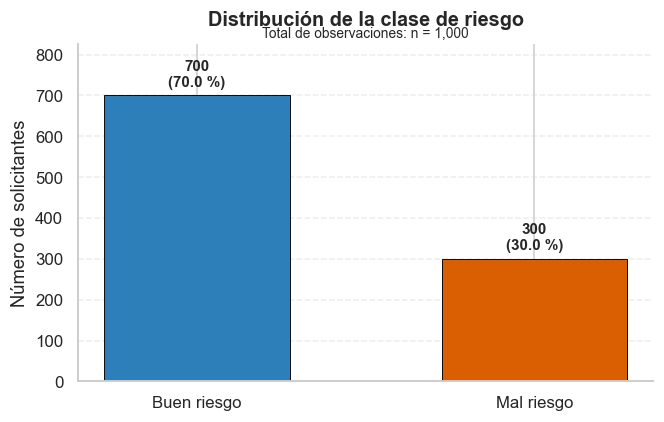

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_01_distribucion_clase_riesgo.png


In [9]:
# Directorios de salida

carpeta_resultados = raiz_proyecto / "resultados"
carpeta_figuras = carpeta_resultados / "figuras"
carpeta_tablas = carpeta_resultados / "tablas"

carpeta_figuras.mkdir(parents=True, exist_ok=True)
carpeta_tablas.mkdir(parents=True, exist_ok=True)

print(f"Resultados: {carpeta_resultados}")
print(f"Figuras: {carpeta_figuras}")
print(f"Tablas: {carpeta_tablas}")


# Figura 1. Distribución de la clase de riesgo

orden_clases = ["Buen riesgo", "Mal riesgo"]
n_total = len(df)

conteo_clases = (
    df["clase_lbl"]
    .value_counts()
    .reindex(orden_clases, fill_value=0)
)

porcentaje_clases = 100 * conteo_clases / n_total

fig, ax = plt.subplots(figsize=(6.2, 4.0))

barras = ax.bar(
    conteo_clases.index,
    conteo_clases.values,
    width=0.55,
    color=["#2c7fb8", "#d95f02"],
    edgecolor="black",
    linewidth=0.6,
)

etiquetas = [
    f"{frecuencia:,}\n({porcentaje:.1f} %)"
    for frecuencia, porcentaje
    in zip(conteo_clases, porcentaje_clases)
]

ax.bar_label(
    barras,
    labels=etiquetas,
    padding=4,
    fontsize=10,
    fontweight="bold",
)

ax.set_title(
    "Distribución de la clase de riesgo",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("")
ax.set_ylabel("Número de solicitantes")
ax.set_ylim(0, conteo_clases.max() * 1.18)

ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.35,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.5,
    1.01,
    f"Total de observaciones: n = {n_total:,}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()

ruta_figura_01 = (
    carpeta_figuras
    / "figura_01_distribucion_clase_riesgo.png"
)

fig.savefig(
    ruta_figura_01,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Figura guardada en: {ruta_figura_01}")

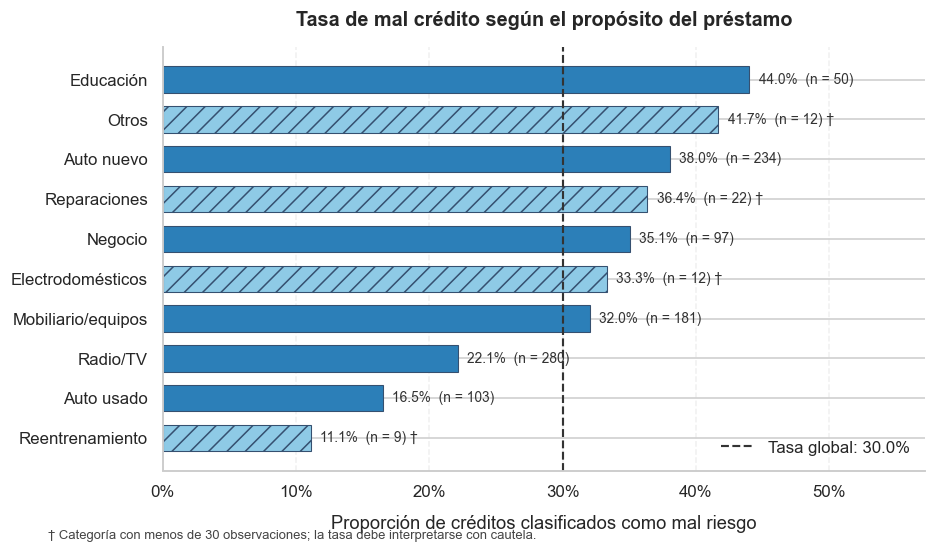

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_02_tasa_mal_credito_por_proposito.png


In [10]:
from matplotlib.ticker import PercentFormatter

# Figura 2. Tasa de mal crédito según el propósito del préstamo

tasa_global = df["mal_credito"].mean()

orden_propositos = (
    tasa_prop
    .sort_values("tasa_mal_credito", ascending=False)
    .index
)

tasas = tasa_prop.loc[orden_propositos, "tasa_mal_credito"]
tamanos = tasa_prop.loc[orden_propositos, "n"]

altura_figura = max(5.2, 0.52 * len(orden_propositos))

fig, ax = plt.subplots(figsize=(9.5, altura_figura))

colores = [
    "#8ecae6" if n < 30 else "#2c7fb8"
    for n in tamanos
]

barras = ax.barh(
    orden_propositos,
    tasas,
    height=0.66,
    color=colores,
    edgecolor="#355070",
    linewidth=0.7,
)

# Diferenciación de las categorías con muestras pequeñas

for barra, n in zip(barras, tamanos):
    if n < 30:
        barra.set_hatch("//")

# Tasa global como referencia

ax.axvline(
    tasa_global,
    color="#333333",
    linestyle="--",
    linewidth=1.4,
    label=f"Tasa global: {tasa_global:.1%}",
)

# Etiquetas de las barras

for barra, tasa, n in zip(barras, tasas, tamanos):
    indicador = " †" if n < 30 else ""

    ax.text(
        tasa + 0.007,
        barra.get_y() + barra.get_height() / 2,
        f"{tasa:.1%}  (n = {n}){indicador}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333",
    )

ax.invert_yaxis()

limite_x = max(
    0.52,
    tasas.max() * 1.30,
)

ax.set_xlim(0, limite_x)
ax.xaxis.set_major_formatter(
    PercentFormatter(xmax=1, decimals=0)
)

ax.set_title(
    "Tasa de mal crédito según el propósito del préstamo",
    fontsize=13,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Proporción de créditos clasificados como mal riesgo",
    labelpad=10,
)

ax.set_ylabel("")

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.30,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right",
    frameon=False,
)

# Nota metodológica fuera del área de los ejes

fig.text(
    0.12,
    0.035,
    "† Categoría con menos de 30 observaciones; la tasa debe interpretarse con cautela.",
    ha="left",
    va="bottom",
    fontsize=8.5,
    color="#444444",
)

# Reserva de espacio inferior para evitar superposiciones

fig.subplots_adjust(
    left=0.23,
    right=0.96,
    top=0.90,
    bottom=0.16,
)

ruta_figura_02 = (
    carpeta_figuras
    / "figura_02_tasa_mal_credito_por_proposito.png"
)

fig.savefig(
    ruta_figura_02,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Figura guardada en: {ruta_figura_02}")

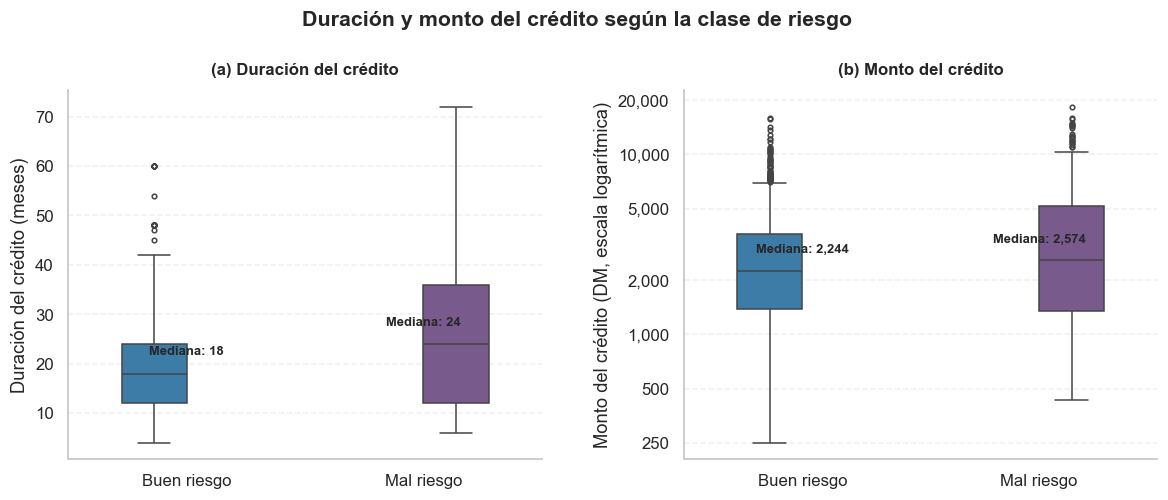

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_03_duracion_monto_por_clase.png


In [11]:
from matplotlib.ticker import FuncFormatter

# Figura 3. Duración y monto del crédito según la clase de riesgo

orden_clases = ["Buen riesgo", "Mal riesgo"]

paleta_riesgo = {
    "Buen riesgo": "#2c7fb8",
    "Mal riesgo": "#7a5195",
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11, 4.8),
)

# Duración del crédito

sns.boxplot(
    data=df,
    x="clase_lbl",
    y="duracion",
    hue="clase_lbl",
    order=orden_clases,
    hue_order=orden_clases,
    palette=paleta_riesgo,
    width=0.55,
    linewidth=1,
    fliersize=3,
    legend=False,
    ax=axes[0],
)

axes[0].set_title(
    "(a) Duración del crédito",
    fontsize=11,
    fontweight="bold",
    pad=10,
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Duración del crédito (meses)")
axes[0].yaxis.grid(True, linestyle="--", alpha=0.30)
axes[0].set_axisbelow(True)


# Monto del crédito

sns.boxplot(
    data=df,
    x="clase_lbl",
    y="monto",
    hue="clase_lbl",
    order=orden_clases,
    hue_order=orden_clases,
    palette=paleta_riesgo,
    width=0.55,
    linewidth=1,
    fliersize=3,
    legend=False,
    ax=axes[1],
)

axes[1].set_yscale("log")

axes[1].set_title(
    "(b) Monto del crédito",
    fontsize=11,
    fontweight="bold",
    pad=10,
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Monto del crédito (DM, escala logarítmica)")

ticks_monto = [250, 500, 1000, 2000, 5000, 10000, 20000]
axes[1].set_yticks(ticks_monto)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda valor, posicion: f"{valor:,.0f}")
)

axes[1].yaxis.grid(True, linestyle="--", alpha=0.30)
axes[1].set_axisbelow(True)


# Medianas por clase

medianas_duracion = (
    df.groupby("clase_lbl", observed=True)["duracion"]
    .median()
    .reindex(orden_clases)
)

medianas_monto = (
    df.groupby("clase_lbl", observed=True)["monto"]
    .median()
    .reindex(orden_clases)
)

for posicion, clase in enumerate(orden_clases):
    axes[0].annotate(
        f"Mediana: {medianas_duracion[clase]:.0f}",
        xy=(posicion, medianas_duracion[clase]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )

    axes[1].annotate(
        f"Mediana: {medianas_monto[clase]:,.0f}",
        xy=(posicion, medianas_monto[clase]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )


# Formato general

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Duración y monto del crédito según la clase de riesgo",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.84,
    bottom=0.14,
    wspace=0.30,
)


# Guardado de la figura

ruta_figura_03 = (
    carpeta_figuras
    / "figura_03_duracion_monto_por_clase.png"
)

fig.savefig(
    ruta_figura_03,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Figura guardada en: {ruta_figura_03}")

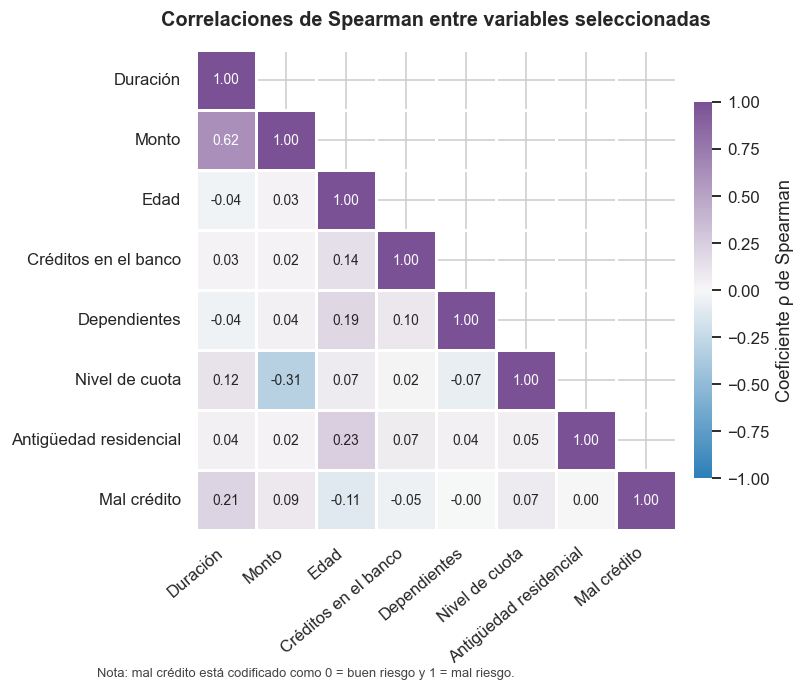

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_04_correlaciones_spearman.png
Matriz guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\tablas\tabla_correlaciones_spearman.csv


In [12]:
from matplotlib.colors import LinearSegmentedColormap

# Figura 4. Correlaciones de Spearman entre variables numéricas,
# ordinales y la clase de riesgo

variables_correlacion = (
    vars_numericas
    + vars_ordinales_codificadas
    + ["mal_credito"]
)

corr_spearman = (
    df[variables_correlacion]
    .corr(method="spearman")
)

etiquetas_correlacion = {
    "duracion": "Duración",
    "monto": "Monto",
    "edad": "Edad",
    "n_creditos_banco": "Créditos en el banco",
    "n_dependientes": "Dependientes",
    "tasa_cuota": "Nivel de cuota",
    "anios_residencia": "Antigüedad residencial",
    "mal_credito": "Mal crédito",
}

corr_grafico = corr_spearman.rename(
    index=etiquetas_correlacion,
    columns=etiquetas_correlacion,
)

# Se oculta el triángulo superior para evitar información duplicada

mascara = np.triu(
    np.ones_like(corr_grafico, dtype=bool),
    k=1,
)

# Paleta divergente sin tonos naranjas

cmap_correlacion = LinearSegmentedColormap.from_list(
    "azul_blanco_purpura",
    ["#2c7fb8", "#f7f7f7", "#7a5195"],
)

tamano = max(7.5, 0.85 * len(corr_grafico))

fig, ax = plt.subplots(
    figsize=(tamano, tamano * 0.86)
)

sns.heatmap(
    corr_grafico,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap=cmap_correlacion,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.7,
    linecolor="white",
    annot_kws={
        "fontsize": 9,
    },
    cbar_kws={
        "label": "Coeficiente ρ de Spearman",
        "shrink": 0.78,
        "pad": 0.03,
    },
    ax=ax,
)

ax.set_title(
    "Correlaciones de Spearman entre variables seleccionadas",
    fontsize=13,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=40,
    ha="right",
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
)

fig.text(
    0.11,
    0.015,
    "Nota: mal crédito está codificado como 0 = buen riesgo y 1 = mal riesgo.",
    ha="left",
    fontsize=8.5,
    color="#444444",
)

fig.subplots_adjust(
    left=0.23,
    right=0.94,
    top=0.90,
    bottom=0.22,
)

ruta_figura_04 = (
    carpeta_figuras
    / "figura_04_correlaciones_spearman.png"
)

fig.savefig(
    ruta_figura_04,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

ruta_tabla_correlaciones = (
    carpeta_tablas
    / "tabla_correlaciones_spearman.csv"
)

corr_spearman.to_csv(
    ruta_tabla_correlaciones,
    encoding="utf-8-sig",
)

plt.show()

print(f"Figura guardada en: {ruta_figura_04}")
print(f"Matriz guardada en: {ruta_tabla_correlaciones}")

### Interpretación de las visualizaciones

La variable respuesta presenta un desbalance moderado: el 70 % de las observaciones corresponde a buenos créditos y el 30 % a malos créditos. Esta distribución no impide el ajuste de modelos de clasificación, pero hace que el *accuracy* sea insuficiente como única medida de desempeño. Por ello, la evaluación posterior deberá complementarse con sensibilidad, especificidad, precisión, F1, curva ROC, AUC y matrices de confusión.

La tasa global observada de mal crédito es de 30 %, pero varía entre los propósitos del préstamo. Educación registra la tasa más alta, con 44.0 %, seguida por Otros, con 41.7 %, y Auto nuevo, con 38.0 %. En contraste, Radio/TV presenta 22.1 %, Auto usado 16.5 % y Reentrenamiento 11.1 %. Estas diferencias son descriptivas y deben interpretarse considerando el tamaño de cada categoría. En particular, Otros, Reparaciones, Electrodomésticos y Reentrenamiento tienen menos de 30 observaciones, por lo que sus tasas son menos estables y no permiten formular conclusiones firmes sin un contraste estadístico adicional.

Los diagramas de caja muestran que los créditos clasificados como mal riesgo presentan duraciones mayores. La mediana pasa de 18 meses en los buenos créditos a 24 meses en los malos, y este último grupo también muestra una dispersión más amplia. Para el monto, la mediana aumenta de 2244 DM a 2574 DM. Sin embargo, existe un solapamiento considerable entre ambas clases y numerosos valores elevados, especialmente en la cola derecha. Por ello, ni la duración ni el monto permiten separar por sí solos los buenos y malos créditos.

La matriz de Spearman muestra una asociación monotónica relativamente alta entre duración y monto, con $\rho=0.62$. Esto indica que los créditos de mayor duración suelen corresponder a montos más elevados. Esta relación podría generar cierta redundancia entre ambos predictores en los modelos multivariados, aunque la presencia de multicolinealidad deberá evaluarse posteriormente mediante diagnósticos específicos, como el factor de inflación de la varianza.

Respecto de la variable respuesta, la duración presenta una asociación positiva débil con el mal crédito ($\rho=0.21$), mientras que la asociación del monto es positiva pero muy débil ($\rho=0.09$). La edad muestra una asociación negativa débil ($\rho=-0.11$), lo que coincide con la menor edad descriptiva observada entre los casos de mal riesgo. Las demás variables incluidas presentan correlaciones cercanas a cero.

En conjunto, las figuras sugieren que la duración, el monto, la edad y el propósito del préstamo contienen información potencialmente relevante para distinguir las clases de riesgo. No obstante, estas relaciones son marginales y exploratorias: no representan efectos ajustados, no demuestran causalidad y pueden modificarse al controlar simultáneamente por otras características del solicitante y del crédito.

## 7. Ajuste paramétrico por máxima verosimilitud

El monto del crédito es una variable positiva y fuertemente asimétrica, por lo que se comparan dos distribuciones adecuadas para este tipo de datos: Lognormal y Gamma. Ambas se ajustan por máxima verosimilitud con `scipy.stats.<distribucion>.fit()`, fijando `loc=0` para respetar el soporte positivo del monto.

Los modelos se comparan mediante la log-verosimilitud, el AIC y gráficos Q–Q. Un AIC menor indica un mejor equilibrio relativo entre ajuste y complejidad, aunque la decisión también debe considerar el comportamiento gráfico, especialmente en las colas.

Para la Lognormal,

$$
X \sim \operatorname{Lognormal}(\mu,\sigma),
$$

se cumple que:

$$
\log(X)\sim\mathcal{N}(\mu,\sigma^2).
$$

Con `loc=0`, los estimadores de máxima verosimilitud son:

$$
\hat{\mu}=\overline{\log x},
\qquad
\hat{\sigma}^{2}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(\log x_i-\hat{\mu}\right)^2.
$$

Se verificará que los parámetros obtenidos con SciPy coincidan con estas expresiones analíticas.

In [13]:
# Ajuste por máxima verosimilitud del monto del crédito

x = df["monto"].to_numpy(dtype=float)

# Verificación del soporte y de la calidad de los datos

if not np.isfinite(x).all():
    raise ValueError(
        "La variable 'monto' contiene valores faltantes o no finitos."
    )

if (x <= 0).any():
    raise ValueError(
        "Las distribuciones Lognormal y Gamma requieren montos positivos."
    )


# Ajuste MLE con el parámetro de localización fijado en cero

sigma_ln, loc_ln, escala_ln = stats.lognorm.fit(
    x,
    floc=0,
)

forma_ga, loc_ga, escala_ga = stats.gamma.fit(
    x,
    floc=0,
)


# Parámetros en notación habitual

mu_ln = np.log(escala_ln)

parametros_lognormal = {
    "mu": mu_ln,
    "sigma": sigma_ln,
}

parametros_gamma = {
    "forma_k": forma_ga,
    "escala_theta": escala_ga,
}


# Log-verosimilitudes maximizadas

log_verosimilitud_ln = stats.lognorm.logpdf(
    x,
    sigma_ln,
    loc=loc_ln,
    scale=escala_ln,
).sum()

log_verosimilitud_ga = stats.gamma.logpdf(
    x,
    forma_ga,
    loc=loc_ga,
    scale=escala_ga,
).sum()


# AIC: ambos modelos tienen dos parámetros libres porque loc = 0

n_parametros = 2

aic_ln = (
    2 * n_parametros
    - 2 * log_verosimilitud_ln
)

aic_ga = (
    2 * n_parametros
    - 2 * log_verosimilitud_ga
)


# Tabla comparativa de los modelos

resultados_mle = pd.DataFrame({
    "distribucion": [
        "Lognormal",
        "Gamma",
    ],
    "parametro_1": [
        mu_ln,
        forma_ga,
    ],
    "nombre_parametro_1": [
        "mu",
        "forma k",
    ],
    "parametro_2": [
        sigma_ln,
        escala_ga,
    ],
    "nombre_parametro_2": [
        "sigma",
        "escala theta",
    ],
    "log_verosimilitud": [
        log_verosimilitud_ln,
        log_verosimilitud_ga,
    ],
    "AIC": [
        aic_ln,
        aic_ga,
    ],
})

resultados_mle["delta_AIC"] = (
    resultados_mle["AIC"]
    - resultados_mle["AIC"].min()
)

resultados_mle = resultados_mle.sort_values(
    "AIC",
    ascending=True,
).reset_index(drop=True)

display(resultados_mle.round(4))


# Verificación analítica del MLE de la Lognormal

log_x = np.log(x)

mu_analitico = log_x.mean()
sigma_analitico = log_x.std(ddof=0)

verificacion_lognormal = pd.DataFrame({
    "parametro": [
        "mu",
        "sigma",
    ],
    "MLE_analitico": [
        mu_analitico,
        sigma_analitico,
    ],
    "MLE_scipy": [
        mu_ln,
        sigma_ln,
    ],
})

verificacion_lognormal["diferencia_absoluta"] = (
    verificacion_lognormal["MLE_analitico"]
    - verificacion_lognormal["MLE_scipy"]
).abs()

verificacion_lognormal["coincide"] = np.isclose(
    verificacion_lognormal["MLE_analitico"],
    verificacion_lognormal["MLE_scipy"],
    rtol=1e-10,
    atol=1e-10,
)

print("\nVerificación del MLE cerrado de la Lognormal:")
display(verificacion_lognormal.round(10))


# Identificación del mejor modelo según AIC

mejor_modelo = resultados_mle.loc[
    0,
    "distribucion",
]

print(
    "Modelo con menor AIC entre los candidatos evaluados: "
    f"{mejor_modelo}"
)


# Exportación de las tablas

ruta_tabla_mle = (
    carpeta_tablas
    / "tabla_ajuste_mle_monto.csv"
)

ruta_tabla_verificacion = (
    carpeta_tablas
    / "tabla_verificacion_mle_lognormal.csv"
)

resultados_mle.to_csv(
    ruta_tabla_mle,
    index=False,
    encoding="utf-8-sig",
)

verificacion_lognormal.to_csv(
    ruta_tabla_verificacion,
    index=False,
    encoding="utf-8-sig",
)

print(f"\nTabla de ajustes guardada en: {ruta_tabla_mle}")
print(
    "Tabla de verificación guardada en: "
    f"{ruta_tabla_verificacion}"
)

,distribucion,parametro_1,nombre_parametro_1,parametro_2,nombre_parametro_2,log_verosimilitud,AIC,delta_AIC
0,Lognormal,7.7887,mu,0.7761,sigma,-8954.1375,17912.2751,0.0000
1,Gamma,1.7921,forma k,1825.3962,escala theta,-9007.2152,18018.4305,106.1554



Verificación del MLE cerrado de la Lognormal:


,parametro,MLE_analitico,MLE_scipy,diferencia_absoluta,coincide
0,mu,7.788691,7.788691,0.0,True
1,sigma,0.776086,0.776086,0.0,True


Modelo con menor AIC entre los candidatos evaluados: Lognormal

Tabla de ajustes guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\tablas\tabla_ajuste_mle_monto.csv
Tabla de verificación guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\tablas\tabla_verificacion_mle_lognormal.csv


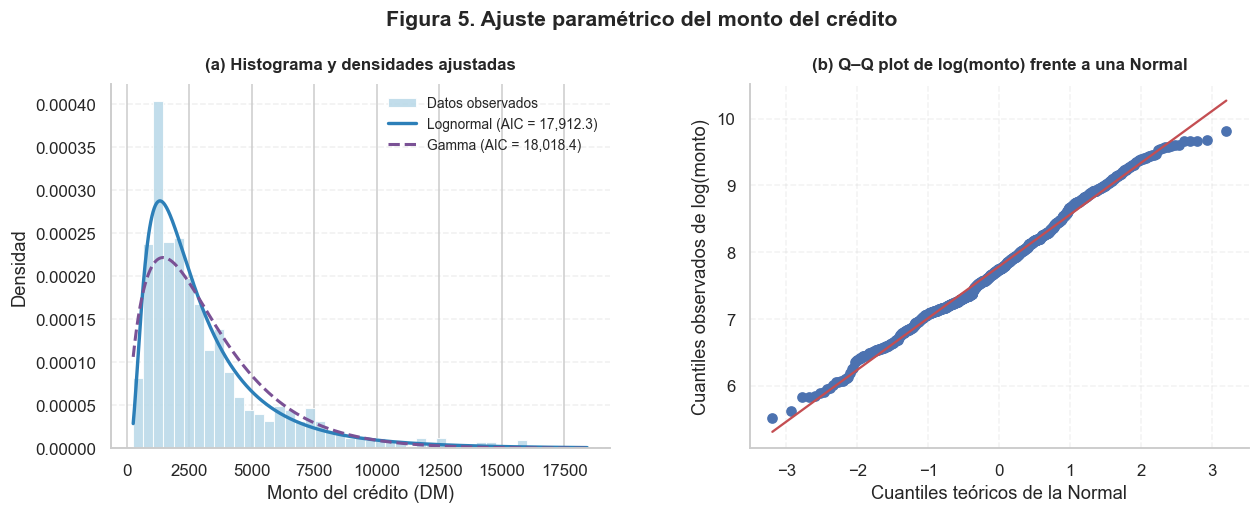

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_05_ajuste_mle_monto.png
AIC Lognormal: 17912.28
AIC Gamma:     18018.43


In [14]:
# Figura 5. Ajuste MLE del monto:
# histograma + densidades y Q–Q plot lognormal

x = np.asarray(x, dtype=float)
x = x[np.isfinite(x) & (x > 0)]

if x.size == 0:
    raise ValueError(
        "No existen observaciones positivas y válidas en x."
    )

# Se fija loc=0 porque ambas distribuciones tienen soporte positivo
par_ln = stats.lognorm.fit(x, floc=0)
par_ga = stats.gamma.fit(x, floc=0)

# Parámetros de la lognormal
sigma_ln, loc_ln, scale_ln = par_ln
mu_ln = np.log(scale_ln)

# Log-verosimilitudes
loglik_ln = np.sum(
    stats.lognorm.logpdf(x, *par_ln)
)

loglik_ga = np.sum(
    stats.gamma.logpdf(x, *par_ga)
)

# Número de parámetros libres:
# shape y scale; loc está fijado en cero
k_ln = 2
k_ga = 2

# Criterio de información de Akaike
aic_ln = 2 * k_ln - 2 * loglik_ln
aic_ga = 2 * k_ga - 2 * loglik_ga



grid = np.linspace(
    max(1, x.min()),
    x.max(),
    800,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.8),
)


# Panel (a): histograma y densidades ajustadas

axes[0].hist(
    x,
    bins=45,
    density=True,
    color="#b8d8e8",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.85,
    label="Datos observados",
)

axes[0].plot(
    grid,
    stats.lognorm.pdf(grid, *par_ln),
    color="#2c7fb8",
    linewidth=2.2,
    label=f"Lognormal (AIC = {aic_ln:,.1f})",
)

axes[0].plot(
    grid,
    stats.gamma.pdf(grid, *par_ga),
    color="#7a5195",
    linestyle="--",
    linewidth=2,
    label=f"Gamma (AIC = {aic_ga:,.1f})",
)

axes[0].set_title(
    "(a) Histograma y densidades ajustadas",
    fontsize=11,
    fontweight="bold",
    pad=10,
)

axes[0].set_xlabel("Monto del crédito (DM)")
axes[0].set_ylabel("Densidad")
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].set_axisbelow(True)


# Panel (b): Q–Q plot estándar de log(monto)

stats.probplot(
    np.log(x),
    dist="norm",
    plot=axes[1],
)

axes[1].set_title(
    "(b) Q–Q plot de log(monto) frente a una Normal",
    fontsize=11,
    fontweight="bold",
    pad=10,
)

axes[1].set_xlabel("Cuantiles teóricos de la Normal")
axes[1].set_ylabel("Cuantiles observados de log(monto)")
axes[1].grid(True, linestyle="--", alpha=0.25)
axes[1].set_axisbelow(True)


for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Figura 5. Ajuste paramétrico del monto del crédito",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.84,
    bottom=0.15,
    wspace=0.28,
)

ruta_figura_05 = (
    carpeta_figuras
    / "figura_05_ajuste_mle_monto.png"
)

fig.savefig(
    ruta_figura_05,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Figura guardada en: {ruta_figura_05}")
print(f"AIC Lognormal: {aic_ln:.2f}")
print(f"AIC Gamma:     {aic_ga:.2f}")

### Síntesis e implicancias del ajuste

La distribución Lognormal presenta el mejor ajuste relativo entre las dos familias evaluadas. Su log-verosimilitud es mayor que la obtenida con la Gamma y su AIC es menor:

$$
\mathrm{AIC}_{\text{Lognormal}}=17912.28,
\qquad
\mathrm{AIC}_{\text{Gamma}}=18018.43.
$$

La diferencia de AIC es:

$$
\Delta\mathrm{AIC}=106.16,
$$

lo que constituye evidencia clara a favor de la Lognormal dentro del conjunto de modelos comparados. Asimismo, los estimadores analíticos de $\mu$ y $\sigma$ coinciden con los obtenidos mediante SciPy, lo que confirma la correcta implementación del ajuste por máxima verosimilitud.

El gráfico Q–Q de $\log(\text{monto})$ presenta un comportamiento aproximadamente lineal en la mayor parte de la distribución, aunque se observan desviaciones leves en las colas. Por tanto, la Lognormal proporciona una representación razonable del monto, pero no debe interpretarse como un ajuste perfecto.

Estos resultados respaldan el uso de `log_monto` en los análisis posteriores, ya que la transformación reduce la asimetría y la influencia relativa de los valores más elevados. En el modelo OLS puede favorecer una relación más estable y una varianza más homogénea, aunque la validez del modelo dependerá finalmente del comportamiento de sus residuos. En la regresión logística, la transformación no responde a un supuesto de normalidad, sino a la búsqueda de una relación funcional más adecuada y menos sensible a valores extremos.

Finalmente, la marcada asimetría del monto justifica complementar la comparación de medias mediante Welch con una prueba basada en rangos, como Mann–Whitney. Ambas pruebas responden a preguntas distintas, por lo que sus resultados se interpretarán de manera conjunta.

 ## 8. Incertidumbre frecuentista: intervalos de confianza

### Proporción global de malos créditos

En esta sección se cuantifica la incertidumbre asociada a la tasa global de mal crédito. Sea:

$$
X=\sum_{i=1}^{n}Y_i \sim \operatorname{Binomial}(n,p),
$$

donde $Y_i=1$ identifica un mal crédito, $p$ es la proporción poblacional desconocida y:

$$
\hat{p}=\frac{X}{n}
$$

es la proporción observada en la muestra.

Para estimar $p$ se construyen dos intervalos de confianza del 95 %. El primero es el **intervalo de Wilson**, solicitado en la consigna:

$$
IC_{Wilson}=
\frac{
\hat p+\frac{z^2}{2n}
\pm
z\sqrt{
\frac{\hat p(1-\hat p)}{n}
+
\frac{z^2}{4n^2}
}
}{
1+\frac{z^2}{n}
}.
$$

Este intervalo suele ofrecer una cobertura más estable que el intervalo de Wald, especialmente cuando la proporción se aleja de 0.5 o el tamaño muestral no es muy grande.

Como contraste, se calcula un **intervalo bootstrap percentil** a partir de $B=10\,000$ remuestras con reemplazo. Este procedimiento aproxima la distribución muestral de $\hat p$ utilizando la distribución empírica de los datos, sin imponer una familia paramétrica específica.

Finalmente, se construye un intervalo basado en la distribución $t$ de Student para la **media de la duración del crédito**:

$$
\bar{x}
\pm
t_{1-\alpha/2,\;n-1}
\frac{s}{\sqrt{n}}.
$$

La comparación entre estos procedimientos permite distinguir la incertidumbre de una proporción binomial de la incertidumbre asociada a la media de una variable cuantitativa. Los intervalos se interpretan en sentido frecuentista: si el procedimiento se repitiera sobre muchas muestras comparables, aproximadamente el 95 % de los intervalos construidos contendría el verdadero parámetro poblacional.

In [15]:
# Parámetros del análisis

nivel_confianza = 0.95
alpha = 1 - nivel_confianza
B = 10_000

y = df["mal_credito"].to_numpy(dtype=np.int8)

if not np.isin(y, [0, 1]).all():
    raise ValueError(
        "La variable 'mal_credito' debe contener únicamente los valores 0 y 1."
    )

n = y.size
x_mal = int(y.sum())
p_hat = y.mean()

z_critico = stats.norm.ppf(1 - alpha / 2)


# Intervalo de Wilson calculado manualmente

denominador = 1 + z_critico**2 / n

centro_wilson = (
    p_hat + z_critico**2 / (2 * n)
) / denominador

margen_wilson = (
    z_critico
    * np.sqrt(
        p_hat * (1 - p_hat) / n
        + z_critico**2 / (4 * n**2)
    )
    / denominador
)

ic_wilson = (
    centro_wilson - margen_wilson,
    centro_wilson + margen_wilson,
)


# Verificación con statsmodels

ic_wilson_sm = tuple(
    proportion_confint(
        count=x_mal,
        nobs=n,
        alpha=alpha,
        method="wilson",
    )
)

wilson_coincide = np.allclose(
    ic_wilson,
    ic_wilson_sm,
    rtol=1e-10,
    atol=1e-10,
)


# Intervalo bootstrap percentil para la proporción

rng = np.random.default_rng(SEED)

boot_p = np.empty(B, dtype=float)
tamano_lote = 1_000

for inicio in range(0, B, tamano_lote):
    fin = min(inicio + tamano_lote, B)
    n_remuestras = fin - inicio

    indices = rng.integers(
        0,
        n,
        size=(n_remuestras, n),
    )

    boot_p[inicio:fin] = y[indices].mean(axis=1)

ic_bootstrap = tuple(
    np.quantile(
        boot_p,
        [alpha / 2, 1 - alpha / 2],
    )
)

error_estandar_bootstrap = boot_p.std(ddof=1)


# Intervalo t para la media de la duración

duracion = (
    df["duracion"]
    .dropna()
    .to_numpy(dtype=float)
)

n_duracion = duracion.size
media_duracion = duracion.mean()
desv_duracion = duracion.std(ddof=1)
error_estandar_duracion = desv_duracion / np.sqrt(n_duracion)

t_critico = stats.t.ppf(
    1 - alpha / 2,
    df=n_duracion - 1,
)

margen_duracion = (
    t_critico * error_estandar_duracion
)

ic_t_duracion = (
    media_duracion - margen_duracion,
    media_duracion + margen_duracion,
)


# Tabla de resultados

resultados_ic = pd.DataFrame([
    {
        "parametro": "Proporción de mal crédito",
        "metodo": "Wilson",
        "estimacion": p_hat,
        "limite_inferior": ic_wilson[0],
        "limite_superior": ic_wilson[1],
        "unidad": "proporción",
    },
    {
        "parametro": "Proporción de mal crédito",
        "metodo": f"Bootstrap percentil (B = {B:,})",
        "estimacion": p_hat,
        "limite_inferior": ic_bootstrap[0],
        "limite_superior": ic_bootstrap[1],
        "unidad": "proporción",
    },
    {
        "parametro": "Media de la duración",
        "metodo": "t de Student",
        "estimacion": media_duracion,
        "limite_inferior": ic_t_duracion[0],
        "limite_superior": ic_t_duracion[1],
        "unidad": "meses",
    },
])

resultados_ic["amplitud"] = (
    resultados_ic["limite_superior"]
    - resultados_ic["limite_inferior"]
)

display(resultados_ic.round(4))


# Resumen en formato interpretable

print(
    f"Malos créditos: {x_mal} de {n} "
    f"({p_hat:.1%})"
)

print(
    f"IC {nivel_confianza:.0%} de Wilson: "
    f"{ic_wilson[0]:.1%} a {ic_wilson[1]:.1%}"
)

print(
    f"IC {nivel_confianza:.0%} bootstrap: "
    f"{ic_bootstrap[0]:.1%} a {ic_bootstrap[1]:.1%}"
)

print(
    f"Error estándar bootstrap: "
    f"{error_estandar_bootstrap:.4f}"
)

print(
    f"\nDuración media: {media_duracion:.2f} meses"
)

print(
    f"IC {nivel_confianza:.0%} t para la duración media: "
    f"{ic_t_duracion[0]:.2f} a "
    f"{ic_t_duracion[1]:.2f} meses"
)

print(
    "\nWilson manual y statsmodels coinciden: "
    f"{wilson_coincide}"
)


# Exportación de los resultados

ruta_tabla_ic = (
    carpeta_tablas
    / "tabla_intervalos_confianza.csv"
)

resultados_ic.to_csv(
    ruta_tabla_ic,
    index=False,
    encoding="utf-8-sig",
)

print(f"\nTabla guardada en: {ruta_tabla_ic}")

,parametro,metodo,estimacion,limite_inferior,limite_superior,unidad,amplitud
0,Proporción de mal crédito,Wilson,0.300,0.2724,0.3291,proporción,0.0567
1,Proporción de mal crédito,"Bootstrap percentil (B = 10,000)",0.300,0.2720,0.3290,proporción,0.0570
2,Media de la duración,t de Student,20.903,20.1547,21.6513,meses,1.4966


Malos créditos: 300 de 1000 (30.0%)
IC 95% de Wilson: 27.2% a 32.9%
IC 95% bootstrap: 27.2% a 32.9%
Error estándar bootstrap: 0.0145

Duración media: 20.90 meses
IC 95% t para la duración media: 20.15 a 21.65 meses

Wilson manual y statsmodels coinciden: True

Tabla guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\tablas\tabla_intervalos_confianza.csv


### Interpretación de los intervalos de confianza

La proporción observada de malos créditos es:

$$
\hat{p}=\frac{300}{1000}=0.300.
$$

El intervalo de Wilson al 95 % sitúa la proporción entre 0.272 y 0.329. En términos porcentuales, la tasa de mal crédito estimada para una población comparable se encuentra aproximadamente entre 27.2 % y 32.9 %.

El intervalo bootstrap percentil produce prácticamente los mismos límites, de 27.2 % a 32.9 %. Esta concordancia es esperable dado el tamaño de la muestra y que la proporción observada no se encuentra cerca de los extremos 0 y 1. Además, el cálculo manual del intervalo de Wilson coincide con la implementación de `statsmodels`, lo que confirma la consistencia del procedimiento.

Para la duración del crédito, la media observada es de 20.90 meses y su intervalo de confianza al 95 % se extiende de 20.15 a 21.65 meses. Este resultado cuantifica la incertidumbre asociada a la duración media, pero no describe la variabilidad entre créditos individuales.

Estos intervalos deben interpretarse en relación con la población representada por el conjunto de datos. La muestra contiene deliberadamente 700 buenos créditos y 300 malos créditos; por ello, la proporción de 30 % caracteriza el dataset analizado y no debe generalizarse automáticamente a cualquier cartera bancaria. La validez externa dependerá de que la población objetivo tenga un proceso de selección y una composición comparables.

## 9. Inferencia mediante frecuencias

### 9.1 ¿La proporción de créditos de riesgo difiere según el propósito?

En esta sección se evalúa si la clasificación del crédito como `riesgo` o `no-riesgo` está asociada con el propósito para el cual fue solicitado.

Si ambas variables fueran independientes, se esperaría que la proporción de créditos de riesgo y no riesgo fuera aproximadamente similar entre los diferentes propósitos. En otras palabras, las frecuencias observadas en cada combinación de categorías deberían ser cercanas a las frecuencias esperadas bajo el supuesto de independencia.

Para evaluar esta relación se utiliza la **prueba chi-cuadrado de independencia**, debido a que ambas variables son categóricas.

La estadística de prueba se define como:

$$
\chi^2 =
\sum_{i=1}^{r}
\sum_{j=1}^{c}
\frac{(O_{ij}-E_{ij})^2}{E_{ij}}
$$

donde:

* $O_{ij}$ representa la frecuencia observada en la celda correspondiente a la fila $i$ y la columna $j$.
* $E_{ij}$ representa la frecuencia esperada bajo la hipótesis de independencia.
* $r$ es el número de categorías de propósito.
* $c$ es el número de categorías de riesgo crediticio.

Las frecuencias esperadas se calculan mediante:

$$
E_{ij}
=

\frac{(\text{total de la fila } i)(\text{total de la columna } j)}
{\text{total de observaciones}}
$$

Los grados de libertad de la prueba se obtienen mediante:

$$
gl=(r-1)(c-1)
$$

Las hipótesis estadísticas son:

$$
H_0:
\text{el propósito del crédito y la clasificación de riesgo son independientes}
$$

$$
H_1:
\text{existe una asociación entre el propósito del crédito y la clasificación de riesgo}
$$

Para que la aproximación de la prueba chi-cuadrado sea adecuada, deben verificarse las siguientes condiciones:

* Ninguna frecuencia esperada debe ser menor que 1.
* Como máximo, el 20 % de las frecuencias esperadas puede ser menor que 5.
* Cada observación debe pertenecer a una sola categoría y ser independiente de las demás.

Una vez verificadas estas condiciones, se compara el valor $p$ con un nivel de significancia de:

$$
\alpha=0.05
$$

La decisión se realiza de la siguiente manera:

* Si $p<0.05$, se rechaza $H_0$ y se concluye que existe evidencia estadística de una asociación entre el propósito del crédito y el nivel de riesgo.
* Si $p\geq0.05$, no se rechaza $H_0$, debido a que no existe evidencia suficiente para afirmar que ambas variables están asociadas.

Es importante señalar que la prueba chi-cuadrado permite determinar si existe una asociación, pero no indica por sí sola qué tan intensa es dicha relación. Por esta razón, se utiliza la **V de Cramér** como medida del tamaño del efecto:

$$
V =
\sqrt{
\frac{\chi^2}
{n\cdot\min(r-1,c-1)}
}
$$

donde $n$ representa el número total de observaciones.

El valor de $V$ se encuentra entre 0 y 1:

* Los valores cercanos a 0 indican una asociación débil o inexistente.
* Los valores cercanos a 1 indican una asociación más fuerte.

Como referencia general, se puede utilizar la siguiente interpretación:

| Valor de V de Cramér | Interpretación aproximada          |
| -------------------: | ---------------------------------- |
|       Menor que 0.10 | Asociación muy débil o inexistente |
|    Entre 0.10 y 0.29 | Asociación pequeña                 |
|    Entre 0.30 y 0.49 | Asociación moderada                |
|           0.50 o más | Asociación fuerte                  |

Estos puntos de corte son orientativos y deben interpretarse considerando el tamaño de la muestra, el número de categorías y el contexto del problema.

Finalmente, en caso de encontrar una asociación estadísticamente significativa, se analizarán los residuos estandarizados de la tabla de contingencia. Esto permitirá identificar qué propósitos presentan una cantidad de créditos de riesgo mayor o menor que la esperada bajo la hipótesis de independencia.


In [16]:
# Tabla de contingencia
tabla = pd.crosstab(
    df["proposito_lbl"],
    df["mal_credito"]
)

n = tabla.to_numpy().sum()
r, c = tabla.shape
alpha = 0.05

# Prueba chi-cuadrado de independencia
chi2, p_chi, gl, esperadas = stats.chi2_contingency(tabla)

# Tamaño del efecto: V de Cramér
V = np.sqrt(
    chi2 / (n * min(r - 1, c - 1))
)

# Frecuencias esperadas
esperadas_df = pd.DataFrame(
    esperadas,
    index=tabla.index,
    columns=tabla.columns
)

n_esp_menor_1 = int((esperadas < 1).sum())
n_esp_menor_5 = int((esperadas < 5).sum())
porc_esp_menor_5 = 100 * n_esp_menor_5 / esperadas.size

# Residuos estandarizados de Pearson
residuos = (
    (tabla - esperadas_df)
    / np.sqrt(esperadas_df)
)

# Clase asociada al crédito de riesgo
clase_riesgo = 1

residuos_riesgo = (
    residuos[[clase_riesgo]]
    .rename(columns={clase_riesgo: "residuo_riesgo"})
    .sort_values("residuo_riesgo", ascending=False)
)

# Resumen de resultados
resultados_chi = pd.DataFrame({
    "n": [n],
    "chi2": [chi2],
    "gl": [gl],
    "p_valor": [p_chi],
    "V_Cramer": [V],
    "esperadas_menor_1": [n_esp_menor_1],
    "esperadas_menor_5": [n_esp_menor_5],
    "porcentaje_menor_5": [porc_esp_menor_5]
})

# Redondeo para presentación
resultados_chi_mostrar = resultados_chi.copy()

resultados_chi_mostrar["chi2"] = (
    resultados_chi_mostrar["chi2"].round(3)
)

resultados_chi_mostrar["p_valor"] = (
    resultados_chi_mostrar["p_valor"].round(5)
)

resultados_chi_mostrar["V_Cramer"] = (
    resultados_chi_mostrar["V_Cramer"].round(3)
)

resultados_chi_mostrar["porcentaje_menor_5"] = (
    resultados_chi_mostrar["porcentaje_menor_5"].round(1)
)

print("Prueba chi-cuadrado: riesgo crediticio según propósito")
display(resultados_chi_mostrar)

print("Tabla de contingencia observada")
display(tabla)

print("Frecuencias esperadas")
display(esperadas_df.round(2))

print("Residuos estandarizados para la clase de riesgo")
display(residuos_riesgo.round(3))

Prueba chi-cuadrado: riesgo crediticio según propósito


,n,chi2,gl,p_valor,V_Cramer,esperadas_menor_1,esperadas_menor_5,porcentaje_menor_5
0,1000,33.356,9,0.00012,0.183,0,3,15.0


Tabla de contingencia observada


mal_credito,0,1
proposito_lbl,,
Auto nuevo,145,89
Auto usado,86,17
Educación,28,22
Electrodomésticos,8,4
Mobiliario/equipos,123,58
Negocio,63,34
Otros,7,5
Radio/TV,218,62
Reentrenamiento,8,1


Frecuencias esperadas


mal_credito,0,1
proposito_lbl,,
Auto nuevo,163.8,70.2
Auto usado,72.1,30.9
Educación,35.0,15.0
Electrodomésticos,8.4,3.6
Mobiliario/equipos,126.7,54.3
Negocio,67.9,29.1
Otros,8.4,3.6
Radio/TV,196.0,84.0
Reentrenamiento,6.3,2.7


Residuos estandarizados para la clase de riesgo


mal_credito,residuo_riesgo
proposito_lbl,
Auto nuevo,2.244
Educación,1.807
Negocio,0.908
Otros,0.738
Reparaciones,0.545
Mobiliario/equipos,0.502
Electrodomésticos,0.211
Reentrenamiento,-1.035
Radio/TV,-2.400


### 9.2 ¿Difieren la duración y el monto entre buenos y malos créditos?

En esta sección se evalúa si la duración y el monto del crédito presentan diferencias entre los créditos clasificados como `riesgo` y `no-riesgo`. Debido a que ambas variables son numéricas y la variable de agrupación es categórica con dos niveles, se utilizarán pruebas de comparación de medias.

### 9.2.1 Análisis de la variable duración

Para comparar la duración promedio entre ambos grupos se aplica la **prueba t de Welch**. Esta prueba es una alternativa a la prueba t de Student y no requiere asumir que las varianzas de los grupos sean iguales.

Las hipótesis estadísticas son:

$$
H_0:\mu_{\text{riesgo}}=\mu_{\text{no-riesgo}}
$$

$$
H_1:\mu_{\text{riesgo}}\neq\mu_{\text{no-riesgo}}
$$

donde $\mu_{\text{riesgo}}$ y $\mu_{\text{no-riesgo}}$ representan las duraciones medias de cada grupo.

Con un nivel de significancia de:

$$
\alpha=0.05
$$

la decisión se realiza de la siguiente manera:

* Si $p<0.05$, se rechaza $H_0$ y se concluye que existen diferencias estadísticamente significativas en la duración media.
* Si $p\geq0.05$, no se rechaza $H_0$, debido a que no existe evidencia suficiente para afirmar que las medias difieren.

La prueba t permite determinar si la diferencia es estadísticamente significativa, pero no indica su magnitud. Para medir el tamaño del efecto se utiliza la **d de Cohen**:

$$
d=
\frac{\bar{x}_1-\bar{x}*2}
{s*{\text{pooled}}}
$$

donde:

* $\bar{x}_1$ y $\bar{x}_2$ son las medias de los grupos.
* $s_{\text{pooled}}$ es la desvi grupos.
* $s_{\text{pooled}}$ es la desviación estándar agrupada.

La desviación estándar agrupada se calcula mediante:

$$
s_{\text{pooled}}=
\sqrt{
\frac{(n_1-1)s_1^2+(n_2-1)s_2^2}
{n_1+n_2-2}
}
$$

Como referencia general, la magnitud absoluta de $d$ puede interpretarse de la siguiente manera:

| Valor absoluto de $d$ | Interpretación aproximada |
| --------------------: | ------------------------- |
|        Menor que 0.20 | Efecto muy pequeño        |
|     Entre 0.20 y 0.49 | Efecto pequeño            |
|     Entre 0.50 y 0.79 | Efecto moderado           |
|            0.80 o más | Efecto grande             |

El signo de $d$ indica la dirección de la diferencia, mientras que su valor absoluto representa la magnitud del efecto. Estos puntos de corte son orientativos y deben interpretarse considerando el contexto del análisis crediticio.


### 9.2.2 Análisis de la variable monto

La variable `monto` presenta una distribución asimétrica y un rango de valores considerablemente amplio. Por esta razón, para comparar los créditos de `riesgo` y `no-riesgo` se utiliza la **prueba U de Mann–Whitney**, una prueba no paramétrica que trabaja con los rangos de las observaciones y no requiere asumir normalidad.

Las hipótesis son:

$$
H_0:
\text{la distribución del monto es similar en ambos grupos}
$$

$$
H_1:
\text{la distribución del monto difiere entre ambos grupos}
$$

Con un nivel de significancia de $\alpha=0.05$, un valor $p<0.05$ indica una diferencia estadísticamente significativa entre los montos de ambos grupos.

Como medida del tamaño del efecto se utiliza la **correlación biserial de rangos**:

$$
r_{rb}=
\frac{2U}{n_1n_2}-1
$$

donde:

* $U$ es el estadístico de Mann–Whitney.
* $n_1$ y $n_2$ son los tamaños de los grupos comparados.

El signo de $r_{rb}$ indica la dirección de la diferencia y depende del orden en que se introducen los grupos. Su valor absoluto representa la magnitud del efecto:

| Valor absoluto de $r_{rb}$ | Interpretación aproximada |
| -------------------------: | ------------------------- |
|             Menor que 0.10 | Efecto muy pequeño        |
|          Entre 0.10 y 0.29 | Efecto pequeño            |
|          Entre 0.30 y 0.49 | Efecto moderado           |
|                 0.50 o más | Efecto grande             |

De manera complementaria, se calcula la **d de Cohen** sobre `log_monto`. La transformación logarítmica reduce la asimetría y limita la influencia de los valores extremos, lo que permite expresar la diferencia entre los grupos en una escala estandarizada más estable.

La prueba de Mann–Whitney constituye el análisis principal del monto, mientras que la d de Cohen sobre el monto transformado se utiliza como una medida complementaria de la magnitud de la diferencia.


In [17]:
# Grupos de comparación
buenos = df.loc[df["mal_credito"] == 0]
malos = df.loc[df["mal_credito"] == 1]

# Tamaño del efecto: d de Cohen
def d_cohen(a, b):
    n1, n2 = len(a), len(b)
    s_pool = np.sqrt(
        ((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1))
        / (n1 + n2 - 2)
    )
    return (a.mean() - b.mean()) / s_pool


# --- Duración: prueba t de Welch ---
dur_malos = malos["duracion"].dropna()
dur_buenos = buenos["duracion"].dropna()

t_w, p_w = stats.ttest_ind(
    dur_malos,
    dur_buenos,
    equal_var=False
)

d_dur = d_cohen(dur_malos, dur_buenos)

print("--- Duración: prueba t de Welch ---")
print(
    f"Media no-riesgo = {dur_buenos.mean():.2f} | "
    f"Media riesgo = {dur_malos.mean():.2f}"
)
print(
    f"t = {t_w:.3f}, p = {p_w:.5f}, "
    f"d de Cohen = {d_dur:.3f}"
)


# --- Monto: prueba U de Mann-Whitney ---
monto_malos = malos["monto"].dropna()
monto_buenos = buenos["monto"].dropna()

U, p_u = stats.mannwhitneyu(
    monto_malos,
    monto_buenos,
    alternative="two-sided"
)

r_rb = 2 * U / (len(monto_malos) * len(monto_buenos)) - 1

# Tamaño del efecto complementario sobre log(monto)
log_monto_malos = malos["log_monto"].dropna()
log_monto_buenos = buenos["log_monto"].dropna()

d_logm = d_cohen(log_monto_malos, log_monto_buenos)

print("\n--- Monto: prueba U de Mann-Whitney ---")
print(
    f"Mediana no-riesgo = {monto_buenos.median():.0f} | "
    f"Mediana riesgo = {monto_malos.median():.0f}"
)
print(
    f"U = {U:.0f}, p = {p_u:.5f}, "
    f"r biserial = {r_rb:.3f}, "
    f"d sobre log(monto) = {d_logm:.3f}"
)

--- Duración: prueba t de Welch ---
Media no-riesgo = 19.21 | Media riesgo = 24.86
t = 6.470, p = 0.00000, d de Cohen = 0.480

--- Monto: prueba U de Mann-Whitney ---
Mediana no-riesgo = 2244 | Mediana riesgo = 2574
U = 116520, p = 0.00592, r biserial = 0.110, d sobre log(monto) = 0.240


### Síntesis de los resultados inferenciales

* **Propósito del crédito:** se rechazó la hipótesis de independencia entre el propósito y el riesgo crediticio, $\chi^2(9)=33.36$, $p=0.00012$. La asociación fue pequeña, con una V de Cramér de $0.183$. Por tanto, el propósito aporta información sobre el riesgo, aunque su capacidad explicativa individual es limitada.

* **Duración:** los créditos de riesgo tuvieron una duración promedio aproximadamente 5.3 meses mayor que los créditos de no riesgo —24.9 frente a 19.2 meses—. La diferencia fue estadísticamente significativa, $p\approx2\times10^{-10}$, con una $d$ de Cohen de aproximadamente $0.48$, correspondiente a un efecto pequeño, pero cercano al nivel moderado.

* **Monto:** los créditos de riesgo presentaron montos generalmente mayores, con medianas de 2574 DM frente a 2244 DM. La prueba de Mann–Whitney mostró una diferencia estadísticamente significativa, $p\approx0.006$, aunque el tamaño del efecto fue pequeño.

Estos resultados representan asociaciones marginales, es decir, analizan cada variable por separado. Debido a que la duración y el monto están correlacionados, con $\rho\approx0.62$, no es posible atribuir el riesgo exclusivamente a uno de estos factores. Su contribución conjunta deberá evaluarse mediante el modelo de regresión logística.


## 10. Regresión lineal: factores asociados con el monto del crédito

En esta sección se analiza qué variables están asociadas con el monto otorgado. Para ello, se utiliza un modelo de **regresión lineal múltiple**, considerando como variables explicativas la duración del crédito, la tasa de la cuota y la edad del solicitante.

Debido a que `monto` presenta una distribución asimétrica, se emplea su transformación logarítmica como variable dependiente.

El modelo se expresa como:

$$
\log(\mathrm{monto}_i)
=

\beta_0
+
\beta_1 \mathrm{duracion}_i
+
\beta_2 \mathrm{tasa_cuota}_i
+
\beta_3 \mathrm{edad}_i
+
\varepsilon_i
$$

Se asume que los errores siguen una distribución normal con media cero y varianza constante:

$$
\varepsilon_i \sim \mathcal{N}(0,\sigma^2)
$$

Cada coeficiente $\beta_j$ representa el cambio esperado en el logaritmo del monto asociado con un incremento de una unidad en la variable correspondiente, manteniendo constantes las demás variables.

Para cada coeficiente se evalúan las siguientes hipótesis:

$$
H_0:\beta_j=0
$$

$$
H_1:\beta_j\neq0
$$

Un valor $p<0.05$ indica que la variable presenta una asociación estadísticamente significativa con el monto del crédito. Esta asociación es condicional a las demás variables incluidas en el modelo y no implica necesariamente causalidad.


In [18]:
modelo_ols = smf.ols("log_monto ~ duracion + tasa_cuota + edad", data=df).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_monto   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     386.4
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          2.04e-166
Time:                        20:19:25   Log-Likelihood:                -779.47
No. Observations:                1000   AIC:                             1567.
Df Residuals:                     996   BIC:                             1587.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.4860      0.074    100.915      0.0

### Diagnóstico de multicolinealidad mediante el VIF

La **multicolinealidad** aparece cuando una variable explicativa está fuertemente relacionada con una combinación lineal de las demás variables del modelo. Este problema no impide necesariamente obtener predicciones, pero puede aumentar la varianza de los coeficientes, volverlos inestables y dificultar su interpretación individual.

Para evaluar la multicolinealidad se utiliza el **Factor de Inflación de la Varianza (VIF)**:

$$
VIF_j=
\frac{1}{1-R_j^2}
$$

donde $R_j^2$ es el coeficiente de determinación obtenido al explicar la variable $X_j$ mediante las demás variables predictoras.

Cuando $R_j^2$ es cercano a 1, significa que $X_j$ puede explicarse en gran medida por las otras variables. En consecuencia, su VIF aumenta y se evidencia un posible problema de multicolinealidad.

Como criterio orientativo, los valores pueden interpretarse de la siguiente manera:

|          VIF | Interpretación aproximada                         |
| -----------: | ------------------------------------------------- |
|    Igual a 1 | No existe relación lineal con las demás variables |
|  Entre 1 y 2 | Colinealidad muy baja                             |
|  Entre 2 y 5 | Colinealidad moderada y generalmente aceptable    |
| Entre 5 y 10 | Multicolinealidad importante; requiere revisión   |
| Mayor que 10 | Multicolinealidad severa                          |

Estos umbrales son referenciales. La evaluación final debe considerar el objetivo del modelo, la estabilidad de los coeficientes y la coherencia teórica de las variables incluidas.


In [19]:
# Colinealidad: factores de inflación de la varianza (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = sm.add_constant(df[["duracion", "tasa_cuota", "edad"]])
vifs = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
    index=["duracion", "tasa_cuota", "edad"], name="VIF")
print(vifs.round(3))

duracion      1.007
tasa_cuota    1.009
edad          1.005
Name: VIF, dtype: float64


### Resultados del modelo de regresión lineal

El modelo de regresión lineal múltiple fue estadísticamente significativo:

$$
F(3,996)=386.4,\qquad p<0.001
$$

El coeficiente de determinación fue:

$$
R^2=0.538
$$

Por tanto, la duración, la tasa de la cuota y la edad explican aproximadamente el **53.8 % de la variabilidad observada en el logaritmo del monto del crédito**.

Manteniendo constantes las demás variables:

* **Duración:** presentó una asociación positiva y significativa con el monto, $\beta=0.0431$, $p<0.001$. Un mes adicional de duración se asocia aproximadamente con un aumento del **4.4 %** en el monto esperado.

* **Tasa de la cuota:** presentó una asociación negativa y significativa, $\beta=-0.2476$, $p<0.001$. Un incremento de una unidad en esta variable se asocia aproximadamente con una reducción del **21.9 %** en el monto esperado.

* **Edad:** mostró una asociación positiva y significativa, aunque de menor magnitud, $\beta=0.0039$, $p=0.009$. Un año adicional de edad se asocia aproximadamente con un aumento del **0.4 %** en el monto esperado.

Los valores del VIF se encontraron muy próximos a 1:

| Variable         |   VIF |
| ---------------- | ----: |
| Duración         | 1.007 |
| Tasa de la cuota | 1.009 |
| Edad             | 1.005 |

Estos resultados indican que no existe un problema relevante de multicolinealidad entre las variables explicativas. En consecuencia, los coeficientes pueden interpretarse de manera individual con mayor estabilidad.

Como evaluación general, la duración fue la variable con mayor asociación positiva con el monto, mientras que la tasa de la cuota presentó una asociación negativa importante. La edad tuvo un efecto estadísticamente significativo, pero comparativamente pequeño.

Las pruebas de normalidad de los residuos resultaron significativas, aunque la asimetría fue reducida y el tamaño de la muestra es amplio. Por ello, conviene complementar el análisis con gráficos de residuos y, si se detecta heterocedasticidad, utilizar errores estándar robustos.


### Diagnóstico de residuos

El análisis de residuos permite evaluar si los supuestos del modelo de regresión lineal son razonables. Para ello, se revisa la relación entre los residuos y los valores ajustados, la normalidad aproximada de los errores y la presencia de observaciones con influencia elevada.

Los principales diagnósticos son:

* **Residuos frente a valores ajustados:** se espera una nube de puntos distribuida alrededor de cero, sin curvaturas ni patrones sistemáticos. Un patrón definido puede indicar falta de linealidad.

* **Homocedasticidad:** la dispersión de los residuos debe mantenerse aproximadamente constante. Una forma de embudo sugiere heterocedasticidad, es decir, una varianza que cambia según el nivel de los valores ajustados.

* **QQ-plot:** compara la distribución de los residuos con una distribución normal. Los puntos deberían mantenerse aproximadamente sobre la línea diagonal. Las desviaciones en los extremos pueden indicar asimetría o valores atípicos.

* **Scale-Location:** permite observar si la magnitud de los residuos estandarizados cambia a lo largo de los valores ajustados. Una línea aproximadamente horizontal respalda el supuesto de varianza constante.

* **Residuos frente a leverage:** identifica observaciones con combinaciones poco comunes de las variables explicativas. La distancia de Cook permite evaluar si estas observaciones ejercen una influencia importante sobre los coeficientes estimados.

La heterocedasticidad también se evalúa formalmente mediante la prueba de **Breusch–Pagan**:

$$
H_0:\text{la varianza de los errores es constante}
$$

$$
H_1:\text{la varianza de los errores no es constante}
$$

Con un nivel de significancia de $\alpha=0.05$, un valor $p<0.05$ indica evidencia de heterocedasticidad. En ese caso, los coeficientes OLS pueden mantenerse, pero conviene utilizar errores estándar robustos para realizar la inferencia.


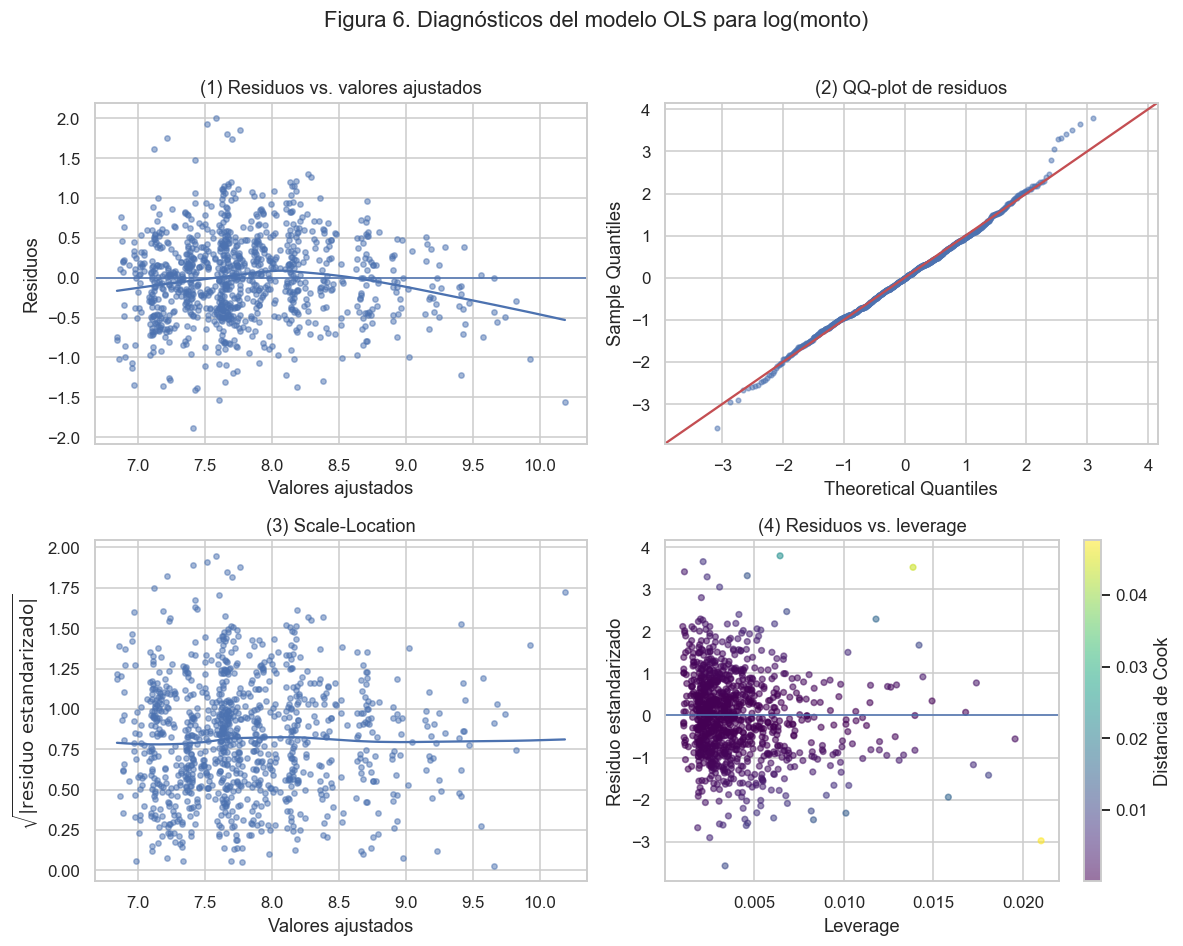

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_06_diagnosticos_modelo_ols.png

--- Prueba de Breusch-Pagan ---
LM = 5.888, p = 0.11716
F = 1.967, p = 0.11733

--- Influencia ---
Distancia de Cook máxima = 0.0476
Umbral exploratorio 4/n = 0.0040
Observaciones sobre el umbral = 52


In [20]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Diagnósticos del modelo
infl = modelo_ols.get_influence()
resid = modelo_ols.resid
fitted = modelo_ols.fittedvalues
resid_std = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks = infl.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

# (1) Residuos vs. valores ajustados
axes[0, 0].scatter(fitted, resid, s=12, alpha=0.5)
axes[0, 0].axhline(0, lw=1)
sns.regplot(
    x=fitted,
    y=resid,
    lowess=True,
    scatter=False,
    line_kws={"lw": 1.5},
    ax=axes[0, 0]
)
axes[0, 0].set(
    xlabel="Valores ajustados",
    ylabel="Residuos",
    title="(1) Residuos vs. valores ajustados"
)

# (2) QQ-plot
sm.qqplot(
    resid,
    line="45",
    fit=True,
    ax=axes[0, 1],
    markersize=3,
    alpha=0.5
)
axes[0, 1].set_title("(2) QQ-plot de residuos")

# (3) Scale-Location
scale_location = np.sqrt(np.abs(resid_std))

axes[1, 0].scatter(
    fitted,
    scale_location,
    s=12,
    alpha=0.5
)
sns.regplot(
    x=fitted,
    y=scale_location,
    lowess=True,
    scatter=False,
    line_kws={"lw": 1.5},
    ax=axes[1, 0]
)
axes[1, 0].set(
    xlabel="Valores ajustados",
    ylabel=r"$\sqrt{|\mathrm{residuo\ estandarizado}|}$",
    title="(3) Scale-Location"
)

# (4) Residuos vs. leverage
sc = axes[1, 1].scatter(
    leverage,
    resid_std,
    c=cooks,
    s=14,
    alpha=0.55,
    cmap="viridis"
)
axes[1, 1].axhline(0, lw=1)
axes[1, 1].set(
    xlabel="Leverage",
    ylabel="Residuo estandarizado",
    title="(4) Residuos vs. leverage"
)
plt.colorbar(
    sc,
    ax=axes[1, 1],
    label="Distancia de Cook"
)

fig.suptitle(
    "Figura 6. Diagnósticos del modelo OLS para log(monto)",
    y=1.01
)
plt.tight_layout()


# Guardado de la figura
ruta_figura_06 = carpeta_figuras / "figura_06_diagnosticos_modelo_ols.png"
fig.savefig(
    ruta_figura_06,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {ruta_figura_06}")

# Prueba de Breusch-Pagan
bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(
    resid,
    modelo_ols.model.exog
)

# Observaciones potencialmente influyentes
umbral_cook = 4 / len(df)
n_influyentes = int((cooks > umbral_cook).sum())

print("\n--- Prueba de Breusch-Pagan ---")
print(f"LM = {bp_lm:.3f}, p = {bp_p:.5f}")
print(f"F = {bp_f:.3f}, p = {bp_f_p:.5f}")

print("\n--- Influencia ---")
print(f"Distancia de Cook máxima = {cooks.max():.4f}")
print(f"Umbral exploratorio 4/n = {umbral_cook:.4f}")
print(f"Observaciones sobre el umbral = {n_influyentes}")

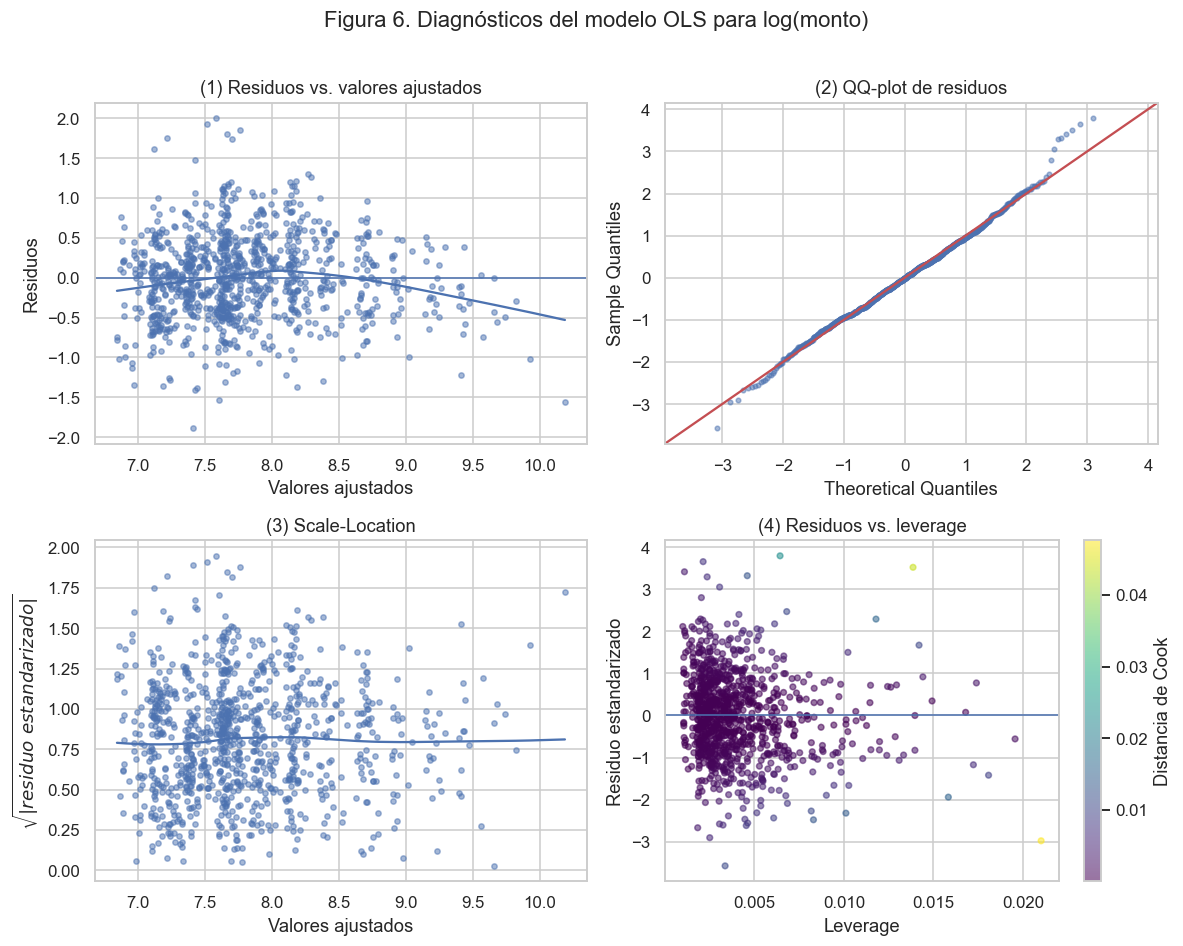

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_06_diagnosticos_modelo_ols.png
--- Prueba de Breusch-Pagan ---
LM = 5.888, p = 0.11716
F = 1.967, p = 0.11733

--- Influencia ---
Distancia de Cook máxima = 0.0476
Umbral exploratorio 4/n = 0.0040
Observaciones sobre el umbral = 52


In [21]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Diagnósticos del modelo
infl = modelo_ols.get_influence()
resid = modelo_ols.resid
fitted = modelo_ols.fittedvalues
resid_std = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks = infl.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

# (1) Residuos vs. valores ajustados
axes[0, 0].scatter(fitted, resid, s=12, alpha=0.5)
axes[0, 0].axhline(0, lw=1)
sns.regplot(
    x=fitted, y=resid, lowess=True, scatter=False,
    line_kws={"lw": 1.5}, ax=axes[0, 0]
)
axes[0, 0].set(
    xlabel="Valores ajustados",
    ylabel="Residuos",
    title="(1) Residuos vs. valores ajustados"
)

# (2) QQ-plot
sm.qqplot(resid, line="45", fit=True, ax=axes[0, 1],
          markersize=3, alpha=0.5)
axes[0, 1].set_title("(2) QQ-plot de residuos")

# (3) Scale-Location
scale_location = np.sqrt(np.abs(resid_std))
axes[1, 0].scatter(fitted, scale_location, s=12, alpha=0.5)
sns.regplot(
    x=fitted, y=scale_location, lowess=True, scatter=False,
    line_kws={"lw": 1.5}, ax=axes[1, 0]
)
axes[1, 0].set(
    xlabel="Valores ajustados",
    ylabel=r"$\sqrt{|residuo\ estandarizado|}$",
    title="(3) Scale-Location"
)

# (4) Residuos vs. leverage
sc = axes[1, 1].scatter(
    leverage, resid_std, c=cooks,
    s=14, alpha=0.55, cmap="viridis"
)
axes[1, 1].axhline(0, lw=1)
axes[1, 1].set(
    xlabel="Leverage",
    ylabel="Residuo estandarizado",
    title="(4) Residuos vs. leverage"
)
plt.colorbar(sc, ax=axes[1, 1], label="Distancia de Cook")

fig.suptitle(
    "Figura 6. Diagnósticos del modelo OLS para log(monto)",
    y=1.01
)
plt.tight_layout()

# Guardar la figura
ruta_figura_06 = carpeta_figuras / "figura_06_diagnosticos_modelo_ols.png"
fig.savefig(
    ruta_figura_06,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {ruta_figura_06}")

# Prueba de Breusch-Pagan
bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(
    resid,
    modelo_ols.model.exog
)

# Observaciones potencialmente influyentes
umbral_cook = 4 / len(df)
n_influyentes = int((cooks > umbral_cook).sum())

print("--- Prueba de Breusch-Pagan ---")
print(f"LM = {bp_lm:.3f}, p = {bp_p:.5f}")
print(f"F = {bp_f:.3f}, p = {bp_f_p:.5f}")

print("\n--- Influencia ---")
print(f"Distancia de Cook máxima = {cooks.max():.4f}")
print(f"Umbral exploratorio 4/n = {umbral_cook:.4f}")
print(f"Observaciones sobre el umbral = {n_influyentes}")

### Evaluación de la normalidad de los residuos

La normalidad de los residuos se evalúa formalmente mediante la prueba de **Shapiro–Wilk** y visualmente mediante el **QQ-plot**.

Las hipótesis son:

$$
H_0:
\text{los residuos siguen una distribución normal}
$$

$$
H_1:
\text{los residuos no siguen una distribución normal}
$$

Con un nivel de significancia de $\alpha=0.05$:

* Si $p\geq0.05$, no se rechaza $H_0$ y la normalidad se considera una aproximación razonable.
* Si $p<0.05$, se rechaza $H_0$ y existe evidencia de desviaciones respecto de la normalidad.

Debido a que la prueba puede ser sensible en muestras grandes, su resultado debe interpretarse junto con el QQ-plot. Si la mayoría de los puntos se mantiene cerca de la línea diagonal y las desviaciones se concentran en las colas, la falta de normalidad puede ser leve y no necesariamente comprometer de forma importante el modelo.


In [22]:
# Prueba de normalidad de Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(resid)

print("--- Prueba de Shapiro-Wilk ---")
print(f"W = {sw_stat:.4f}")
print(f"p = {sw_p:.5f}")

--- Prueba de Shapiro-Wilk ---
W = 0.9951
p = 0.00275


### Evaluación de la homocedasticidad: prueba de Breusch–Pagan

La prueba de **Breusch–Pagan** permite evaluar si la varianza de los residuos se mantiene constante a lo largo de los valores explicados por el modelo.

Las hipótesis son:

$$
H_0:
\text{los residuos presentan varianza constante}
$$

$$
H_1:
\text{la varianza de los residuos no es constante}
$$

Con un nivel de significancia de $\alpha=0.05$:

* Si $p\geq0.05$, no se rechaza $H_0$ y la homocedasticidad se considera una suposición razonable.
* Si $p<0.05$, se rechaza $H_0$ y existe evidencia de heterocedasticidad.

El resultado debe interpretarse junto con los gráficos de residuos. En caso de detectar heterocedasticidad, se recomienda estimar errores estándar robustos para mejorar la validez de las pruebas de significancia.


In [23]:
# Prueba de Breusch-Pagan
bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(
    resid,
    modelo_ols.model.exog
)

print("--- Prueba de Breusch-Pagan ---")
print(f"LM = {bp_stat:.3f}, p = {bp_p:.5f}")
print(f"F = {bp_f:.3f}, p = {bp_f_p:.5f}")

--- Prueba de Breusch-Pagan ---
LM = 5.888, p = 0.11716
F = 1.967, p = 0.11733


### Inferencia con errores estándar robustos HC3

Cuando existe heterocedasticidad, los errores estándar clásicos del modelo OLS pueden ser inadecuados. Para obtener una inferencia más confiable se utilizan errores estándar robustos de tipo **HC3**.

Esta corrección no modifica los coeficientes estimados ni las predicciones del modelo. Sin embargo, ajusta:

* los errores estándar;
* los estadísticos de prueba;
* los valores $p$;
* los intervalos de confianza.

HC3 es especialmente útil cuando existen observaciones con leverage elevado o cuando la varianza de los residuos no es constante. La comparación con la estimación clásica permite verificar si las conclusiones sobre la significancia de las variables se mantienen después de aplicar la corrección.


In [24]:
# Modelo con errores estándar robustos HC3
modelo_hc3 = modelo_ols.get_robustcov_results(cov_type="HC3")

tabla_hc3 = pd.DataFrame({
    "coeficiente": modelo_ols.params,
    "EE_clasico": modelo_ols.bse,
    "EE_HC3": modelo_hc3.bse,
    "p_clasico": modelo_ols.pvalues,
    "p_HC3": modelo_hc3.pvalues
})

print("--- Comparación de la inferencia clásica y robusta HC3 ---")
display(tabla_hc3.round(4))

--- Comparación de la inferencia clásica y robusta HC3 ---


,coeficiente,EE_clasico,EE_HC3,p_clasico,p_HC3
Intercept,7.4860,0.0742,0.0748,0.0000,0.0000
duracion,0.0431,0.0014,0.0015,0.0000,0.0000
tasa_cuota,-0.2476,0.0150,0.0156,0.0000,0.0000
edad,0.0039,0.0015,0.0016,0.0088,0.0144


### Validación cruzada k-fold $(k=5)$

Para evaluar la capacidad de generalización del modelo se utiliza **validación cruzada de 5 particiones**. El conjunto de datos se divide aleatoriamente en cinco grupos de tamaño similar. En cada iteración, cuatro grupos se utilizan para entrenar el modelo y el restante para evaluarlo.

El procedimiento se repite cinco veces, de manera que cada observación sea utilizada una vez como parte del conjunto de prueba.

El desempeño se evalúa mediante:

* **$R^2$:** proporción de la variabilidad de `log_monto` explicada en datos no utilizados durante el entrenamiento. Valores mayores indican mejor capacidad explicativa.
* **RMSE:** error cuadrático medio expresado en la escala de `log_monto`. Valores menores indican predicciones más precisas.

Finalmente, se comparan el $R^2$ promedio de validación cruzada y el $R^2$ obtenido con la muestra completa. Resultados similares sugieren que el desempeño del modelo es estable y que no existe evidencia importante de sobreajuste.


In [25]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_ols = df[["duracion", "tasa_cuota", "edad"]].values
y_ols = df["log_monto"].values

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = []

for fold, (i_train, i_test) in enumerate(kf.split(X_ols), start=1):
    modelo_cv = LinearRegression().fit(X_ols[i_train], y_ols[i_train])
    pred = modelo_cv.predict(X_ols[i_test])

    resultados_cv.append({
        "fold": fold,
        "R2": r2_score(y_ols[i_test], pred),
        "RMSE": np.sqrt(mean_squared_error(y_ols[i_test], pred))
    })

cv_ols = pd.DataFrame(resultados_cv).set_index("fold")

print("--- Validación cruzada del modelo lineal ---")
display(cv_ols.round(4))

print(f"R2 medio = {cv_ols['R2'].mean():.4f} ± {cv_ols['R2'].std():.4f}")
print(f"RMSE medio = {cv_ols['RMSE'].mean():.4f} en escala logarítmica")
print(f"R2 del modelo completo = {modelo_ols.rsquared:.4f}")

--- Validación cruzada del modelo lineal ---


,R2,RMSE
fold,,
1,0.5321,0.5776
2,0.4972,0.5292
3,0.5943,0.4959
4,0.5439,0.4861
5,0.4901,0.5561


R2 medio = 0.5315 ± 0.0418
RMSE medio = 0.5290 en escala logarítmica
R2 del modelo completo = 0.5379


### Conclusiones del modelo de regresión lineal

El modelo de regresión lineal múltiple fue globalmente significativo y explicó aproximadamente el **53.8 % de la variabilidad de `log_monto`**:

$$
R^2=0.538,\qquad R^2_{\mathrm{ajustado}}=0.537
$$

El desempeño obtenido mediante validación cruzada fue similar, con un $R^2$ promedio cercano a $0.53$. Esta proximidad respecto al ajuste obtenido con la muestra completa indica una capacidad de generalización estable y no muestra evidencia importante de sobreajuste.

La **duración del crédito** presentó la asociación positiva más clara con el monto. Manteniendo constantes la tasa de la cuota y la edad, un mes adicional de duración se relacionó con un aumento aproximado del **4.4 %** en el monto esperado.

La **tasa de la cuota** mostró una asociación negativa: mayores porcentajes del ingreso destinados al pago de la cuota se relacionaron con montos de crédito más bajos. La **edad** presentó una asociación positiva de menor magnitud, pero se mantuvo estadísticamente significativa incluso al utilizar errores estándar robustos HC3.

Los valores del VIF fueron cercanos a 1 para todas las variables, por lo que no se identificaron problemas relevantes de multicolinealidad. Esto permite interpretar los coeficientes con mayor estabilidad.

Respecto a los supuestos del modelo, la prueba de Breusch–Pagan no encontró evidencia de heterocedasticidad:

$$
p=0.117
$$

Por tanto, la hipótesis de varianza constante de los errores resulta razonable. Además, los errores estándar robustos HC3 fueron muy similares a los errores estándar clásicos y no modificaron las conclusiones sobre la significancia de las variables.

Aunque la prueba de Shapiro–Wilk rechazó la normalidad estricta de los residuos, esta desviación debe interpretarse considerando el tamaño de la muestra, $n=1000$, ya que estas pruebas son sensibles incluso a diferencias pequeñas. En conjunto con el QQ-plot, la baja asimetría de los residuos y la estabilidad de la inferencia robusta, no se observa un impacto práctico importante sobre las conclusiones.

Finalmente, no se identificaron observaciones con una influencia excesiva según la distancia de Cook. En conjunto, los diagnósticos respaldan que el modelo ofrece una representación razonable, estable e interpretable de los factores asociados con el monto del crédito.


## 11. Regresión logística: factores asociados con el riesgo crediticio

En esta sección se modela la probabilidad de que un crédito sea clasificado como riesgoso. La variable respuesta se define como:

$$
Y_i=
\begin{cases}
1, & \text{si el crédito es de riesgo} \
0, & \text{si el crédito es de no riesgo}
\end{cases}
$$

La regresión logística relaciona las variables explicativas con la probabilidad de mal crédito mediante la función logística:

$$
P(Y_i=1\mid \mathbf{x}_i)
=

\frac{1}
{1+\exp\left(-\mathbf{x}_i^{\mathsf{T}}\boldsymbol{\beta}\right)}
$$

De manera equivalente, el modelo puede expresarse en términos del logaritmo de las *odds*:

$$
\log
\left(
\frac{P(Y_i=1\mid\mathbf{x}_i)}
{1-P(Y_i=1\mid\mathbf{x}_i)}
\right)
=

\beta_0+\beta_1x_{i1}+\cdots+\beta_px_{ip}
$$

Para cada predictor, el valor:

$$
OR_j=\exp(\beta_j)
$$

corresponde al **odds ratio**. Este indicador representa el factor multiplicativo sobre las *odds* de mal crédito asociado con un incremento de una unidad en el predictor, manteniendo constantes las demás variables.

Su interpretación general es:

* $OR_j>1$: el predictor se asocia con mayores *odds* de mal crédito.
* $OR_j<1$: el predictor se asocia con menores *odds* de mal crédito.
* $OR_j=1$: no se observa cambio en las *odds*.

Para las variables categóricas, cada odds ratio se interpreta respecto de una categoría de referencia.

### Variables incluidas

El modelo utiliza variables respaldadas por el análisis exploratorio y por su relevancia en el contexto crediticio:

* estado de la cuenta corriente;
* duración del crédito;
* logaritmo del monto;
* historial crediticio;
* nivel de ahorros;
* antigüedad laboral;
* tasa de la cuota;
* edad;
* tipo de vivienda;
* otros planes de pago.

Las variables categóricas se transformarán mediante codificación indicadora, dejando una categoría de referencia para evitar redundancia perfecta.

### Estrategia de entrenamiento y evaluación

El procedimiento seguirá los siguientes pasos:

1. División estratificada de los datos en 70 % para entrenamiento y 30 % para prueba, manteniendo aproximadamente la proporción de créditos de riesgo en ambos conjuntos.
2. Ajuste del modelo únicamente con el conjunto de entrenamiento.
3. Validación cruzada estratificada de cinco particiones para evaluar la estabilidad del AUC.
4. Evaluación final sobre el conjunto de prueba mediante matriz de confusión, precisión, recall, especificidad, F1-score y AUC-ROC.
5. Interpretación de los coeficientes mediante odds ratios e intervalos de confianza.

La estratificación es importante porque la variable objetivo no está equilibrada: aproximadamente el 30 % de los créditos pertenece a la clase de riesgo.

### Pseudo-$R^2$ de McFadden

En la regresión logística no existe un coeficiente de determinación directamente equivalente al $R^2$ de la regresión lineal. Como medida complementaria de ajuste se utiliza el **pseudo-$R^2$ de McFadden**:

$$
R^2_{\mathrm{McFadden}}
=

1-
\frac{\log L_{\mathrm{modelo}}}
{\log L_{\mathrm{nulo}}}
$$

donde:

* $\log L_{\mathrm{modelo}}$ es la log-verosimilitud del modelo ajustado.
* $\log L_{\mathrm{nulo}}$ es la log-verosimilitud del modelo que solo contiene el intercepto.

Un valor mayor indica que el modelo mejora respecto del modelo nulo. Como referencia orientativa:

| Pseudo-$R^2$ de McFadden | Interpretación aproximada        |
| -----------------------: | -------------------------------- |
|           Menor que 0.10 | Mejora limitada                  |
|        Entre 0.10 y 0.20 | Ajuste aceptable                 |
|        Entre 0.20 y 0.40 | Buen ajuste                      |
|           Mayor que 0.40 | Ajuste muy alto y poco frecuente |

Estos umbrales no deben interpretarse como equivalentes a los del $R^2$ lineal. La evaluación principal del modelo se realizará mediante su capacidad discriminativa, su desempeño fuera de muestra y la estabilidad de sus coeficientes.


In [26]:
from sklearn.model_selection import train_test_split

FORMULA_LOGIT = ("mal_credito ~ C(estado_cuenta) + duracion + log_monto"
                 " + C(historial_credito) + C(ahorros) + C(empleo_actual)"
                 " + tasa_cuota + edad + C(vivienda) + C(otros_planes_pago)")

df_train, df_test = train_test_split(df, test_size=0.30, random_state=SEED,
                                     stratify=df["mal_credito"])
print(f"Entrenamiento: {len(df_train)} obs. (tasa mal crédito = {df_train['mal_credito'].mean():.3f})")
print(f"Prueba       : {len(df_test)} obs. (tasa mal crédito = {df_test['mal_credito'].mean():.3f})")

modelo_logit = smf.logit(FORMULA_LOGIT, data=df_train).fit(disp=0)

### revisar el pseudo-r2
print(f"\nPseudo-R2 de McFadden (train): {modelo_logit.prsquared:.4f}")
print(f"Convergencia: {modelo_logit.mle_retvals['converged']}")

Entrenamiento: 700 obs. (tasa mal crédito = 0.300)
Prueba       : 300 obs. (tasa mal crédito = 0.300)

Pseudo-R2 de McFadden (train): 0.2202
Convergencia: True


### Interpretación del valor $p$ en la regresión logística

En la regresión logística, cada coeficiente se evalúa mediante una prueba de hipótesis para determinar si la variable explicativa está asociada con la probabilidad del evento de interés.

Las hipótesis son:

$$
H_0:\beta_j=0
$$

$$
H_1:\beta_j\neq0
$$

donde $\beta_j$ representa el coeficiente asociado con la variable $j$.

El valor $p$ indica qué tan compatibles son los resultados observados con la hipótesis nula. Valores pequeños proporcionan mayor evidencia en contra de $H_0$.

Con un nivel de significancia de:

$$
\alpha=0.05
$$

la decisión se realiza de la siguiente manera:

* Si $p<0.05$, se rechaza $H_0$ y se concluye que la variable presenta una asociación estadísticamente significativa con la probabilidad de mal crédito, manteniendo constantes las demás variables.
* Si $p\geq0.05$, no se rechaza $H_0$, debido a que no existe evidencia suficiente para afirmar que la variable esté asociada con la respuesta.

El valor $p$ no mide la magnitud ni la importancia práctica de la asociación. Por esta razón, debe interpretarse junto con el **odds ratio** y su intervalo de confianza del 95 %:

$$
OR_j=\exp(\beta_j)
$$

La interpretación del intervalo de confianza es la siguiente:

* Si el intervalo de confianza del 95 % del $OR$ no contiene el valor 1, la asociación se considera estadísticamente significativa al nivel del 5 %.
* Si el intervalo contiene el valor 1, no existe evidencia suficiente para afirmar que el predictor esté asociado con la respuesta.

Además, un $OR>1$ indica mayores *odds* de mal crédito, mientras que un $OR<1$ indica menores *odds*, siempre en comparación con la categoría de referencia o por cada unidad adicional del predictor.


In [27]:
# Odds ratios con IC 95% (referencias: A11 '< 0 DM', A30, A61, A71, A141, A151)
or_tabla = pd.DataFrame({
    "OR": np.exp(modelo_logit.params),
    "IC 2.5%": np.exp(modelo_logit.conf_int()[0]),
    "IC 97.5%": np.exp(modelo_logit.conf_int()[1]),
    "p-valor": modelo_logit.pvalues,
}).drop(index="Intercept").sort_values("OR")
or_tabla.round(4)

,OR,IC 2.5%,IC 97.5%,p-valor
C(ahorros)[T.A64],0.1617,0.0349,0.7495,0.0199
C(estado_cuenta)[T.A14],0.1803,0.1079,0.3014,0.0000
C(historial_credito)[T.A34],0.2413,0.0910,0.6403,0.0043
C(estado_cuenta)[T.A13],0.3121,0.1384,0.7038,0.0050
C(empleo_actual)[T.A74],0.4037,0.1632,0.9987,0.0497
C(ahorros)[T.A65],0.4303,0.2421,0.7647,0.0041
C(historial_credito)[T.A33],0.4360,0.1506,1.2617,0.1257
C(historial_credito)[T.A32],0.4765,0.1893,1.1990,0.1154
C(ahorros)[T.A63],0.4809,0.1972,1.1731,0.1076
C(vivienda)[T.A152],0.5868,0.3552,0.9694,0.0374


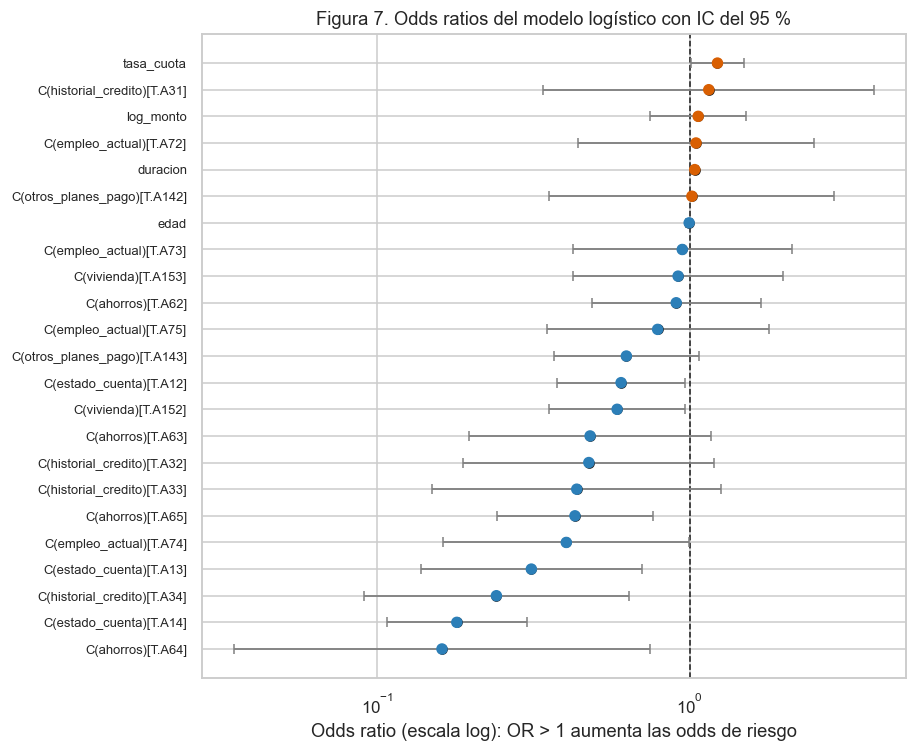

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_07_odds_ratios_modelo_logistico.png


In [28]:
# Figura 7. Odds ratios con IC 95%:
# factores asociados con mayor y menor riesgo

fig, ax = plt.subplots(figsize=(8.5, 7))

tab = or_tabla.sort_values("OR")
colores = [
    "#2c7fb8" if valor < 1 else "#d95f02"
    for valor in tab["OR"]
]

ax.errorbar(
    tab["OR"],
    range(len(tab)),
    xerr=[
        tab["OR"] - tab["IC 2.5%"],
        tab["IC 97.5%"] - tab["OR"]
    ],
    fmt="o",
    ecolor="gray",
    elinewidth=1.2,
    capsize=3,
    markerfacecolor="white",
    markeredgecolor="k",
    zorder=3
)

ax.scatter(
    tab["OR"],
    range(len(tab)),
    c=colores,
    s=42,
    zorder=4
)

ax.axvline(1, color="k", linestyle="--", linewidth=1)

ax.set_yticks(range(len(tab)))
ax.set_yticklabels(tab.index, fontsize=8.5)
ax.set_xscale("log")

ax.set_xlabel(
    "Odds ratio (escala log): OR > 1 aumenta las odds de riesgo"
)
ax.set_title(
    "Figura 7. Odds ratios del modelo logístico con IC del 95 %"
)

plt.tight_layout()

# Guardar la figura
ruta_figura_07 = (
    carpeta_figuras / "figura_07_odds_ratios_modelo_logistico.png"
)

fig.savefig(
    ruta_figura_07,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {ruta_figura_07}")

### Conclusión preliminar sobre los factores asociados con el riesgo crediticio

Los resultados preliminares de la regresión logística muestran que el riesgo crediticio está asociado principalmente con la **duración del préstamo**, la **tasa de la cuota**, el **estado de la cuenta corriente**, el **nivel de ahorros**, el **historial crediticio** y la **situación de vivienda**.

Los créditos de mayor duración y con una tasa de cuota más elevada presentan mayores *odds* de mal crédito. En particular, cada mes adicional de duración incrementa las *odds* aproximadamente en un 3.9 %, mientras que una unidad adicional en la tasa de la cuota se relaciona con un aumento cercano al 23 %, manteniendo constantes las demás variables.

En contraste, determinadas categorías asociadas con una mejor situación financiera presentan menores *odds* de riesgo. Destacan la ausencia de una cuenta corriente registrada, los saldos más favorables, los niveles elevados o no declarados de ahorro, ciertos antecedentes crediticios y la vivienda propia. Estas asociaciones deben interpretarse siempre respecto de sus correspondientes categorías de referencia.

El monto del crédito mostró diferencias entre buenos y malos créditos en el análisis bivariado. Sin embargo, dejó de ser significativo al controlar simultáneamente por las demás variables. Esto sugiere que su asociación inicial estaba parcialmente explicada por factores relacionados, especialmente la duración del préstamo.

El modelo alcanzó un pseudo-$R^2$ de McFadden de $0.2202$, considerado un ajuste adecuado para una regresión logística, y mantuvo la misma proporción de malos créditos en los conjuntos de entrenamiento y prueba. En conjunto, los resultados indican que el riesgo no depende de una sola característica, sino de la combinación entre las condiciones del préstamo y la situación financiera previa del solicitante.

Estas conclusiones son preliminares y deberán complementarse con las métricas de desempeño sobre el conjunto de prueba, la validación cruzada y el análisis de la capacidad discriminativa del modelo.


### 11.1 Evaluación del clasificador: ROC–AUC, KS, matriz de confusión, precisión y recall

Para evaluar el desempeño del modelo se considera como clase positiva el **mal crédito**. Por tanto, una predicción positiva indica que el solicitante es clasificado como riesgoso.

La matriz de confusión resume cuatro posibles resultados:

* **Verdadero positivo (TP):** el modelo identifica correctamente un mal crédito.
* **Falso positivo (FP):** un buen crédito es clasificado como riesgoso.
* **Verdadero negativo (TN):** el modelo identifica correctamente un buen crédito.
* **Falso negativo (FN):** un mal crédito es clasificado como bueno.

En este problema, los errores no tienen el mismo costo. Un falso negativo implica aprobar a un cliente que posteriormente podría incumplir, por lo que se le asigna un costo de 5. Un falso positivo implica rechazar a un buen cliente y perder una oportunidad de negocio, con un costo de 1.

#### Recall o sensibilidad

$$
\mathrm{Recall}
=

\frac{TP}{TP+FN}
$$

Mide la proporción de malos créditos que el modelo identifica correctamente. Un recall alto reduce la cantidad de clientes riesgosos aprobados por error.

#### Precisión

$$
\mathrm{Precision}
=

\frac{TP}{TP+FP}
$$

Indica qué proporción de los créditos clasificados como riesgosos corresponde realmente a malos créditos. Una precisión alta reduce el rechazo innecesario de buenos clientes.

#### Especificidad

$$
\mathrm{Especificidad}
=

\frac{TN}{TN+FP}
$$

Mide la proporción de buenos créditos identificados correctamente. Esta métrica permite evaluar qué tan bien el modelo evita clasificar como riesgosos a clientes que podrían cumplir con sus pagos.

#### ROC–AUC

La curva ROC representa la relación entre la sensibilidad y la tasa de falsos positivos para distintos umbrales de clasificación. El área bajo esta curva, denominada **ROC–AUC**, mide la capacidad general del modelo para ordenar a los clientes según su nivel de riesgo.

Un AUC de 0.5 indica una capacidad discriminativa similar al azar, mientras que valores cercanos a 1 representan una mejor separación entre buenos y malos créditos. Esta métrica no depende de un único umbral de decisión.

#### Estadístico KS de Kolmogorov–Smirnov

El estadístico **KS** se utiliza con frecuencia en modelos de *credit scoring* para medir la separación entre las distribuciones de los puntajes asignados a los créditos de riesgo y de no riesgo.

Se define como la máxima diferencia absoluta entre sus funciones de distribución acumulada:

$$
KS
=

\max_x
\left|
F_{\mathrm{riesgo}}(x)
-

F_{\mathrm{no\ riesgo}}(x)
\right|
$$

Un valor elevado indica que el modelo separa mejor ambos grupos. Como referencia general:

|       Valor de KS | Interpretación aproximada          |
| ----------------: | ---------------------------------- |
|    Menor que 0.20 | Capacidad discriminativa débil     |
| Entre 0.20 y 0.40 | Capacidad discriminativa razonable |
|    Mayor que 0.40 | Capacidad discriminativa fuerte    |

Estos umbrales son orientativos y deben interpretarse considerando el conjunto de datos, el tipo de score y las necesidades del negocio.

Debido a que el costo de un falso negativo es mayor que el de un falso positivo, el umbral final no debe seleccionarse únicamente con el valor predeterminado de 0.5. Se debe buscar un punto de operación que mantenga un recall elevado y minimice el costo total esperado de clasificación.


In [29]:
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)

p_test = modelo_logit.predict(df_test)          # probabilidades predichas en prueba
y_test = df_test["mal_credito"].values

auc_test = roc_auc_score(y_test, p_test)
fpr, tpr, umbrales_roc = roc_curve(y_test, p_test)

# Estadístico KS (máxima separación entre TPR y FPR, usual en scoring crediticio)
ks = float(np.max(tpr - fpr))
umbral_ks = float(umbrales_roc[np.argmax(tpr - fpr)])

print(f"ROC-AUC (test, n = {len(df_test)}): {auc_test:.4f}")
print(f"Estadístico KS: {ks:.4f} (alcanzado en umbral = {umbral_ks:.3f})")

ROC-AUC (test, n = 300): 0.7740
Estadístico KS: 0.4810 (alcanzado en umbral = 0.369)


In [30]:
# Estabilidad: AUC por validación cruzada estratificada de 5 folds (pipeline sklearn)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

cat_logit = ["estado_cuenta", "historial_credito", "ahorros", "empleo_actual",
             "vivienda", "otros_planes_pago"]
num_logit = ["duracion", "log_monto", "tasa_cuota", "edad"]

pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), cat_logit),
        ("num", StandardScaler(), num_logit),
    ])),
    ("clf", LogisticRegression(max_iter=2000, C=1e6)),   # C alto ~ sin regularización (comparable a MLE)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
aucs_cv = cross_val_score(pipe, df[cat_logit + num_logit], df["mal_credito"],
                          cv=skf, scoring="roc_auc")
print("AUC por fold:", np.round(aucs_cv, 4))
print(f"AUC CV 5-fold: {aucs_cv.mean():.4f} ± {aucs_cv.std():.4f}")

AUC por fold: [0.7785 0.7744 0.8013 0.7485 0.7399]
AUC CV 5-fold: 0.7685 ± 0.0221


### Capacidad discriminativa y estabilidad del modelo

El modelo obtuvo un ROC–AUC de $0.774$ en el conjunto de prueba, resultado muy próximo al AUC medio de la validación cruzada:

$$
AUC_{\mathrm{CV}}=0.7685\pm0.0221
$$

Esta consistencia indica que la capacidad discriminativa del modelo es estable entre las distintas particiones y que no se observa una brecha importante entre entrenamiento y prueba. Por tanto, no existe evidencia relevante de sobreajuste.

El estadístico $KS=0.481$, alcanzado en un umbral de $0.369$, muestra una separación fuerte entre los puntajes de los créditos de riesgo y de no riesgo. En conjunto, el AUC y el KS indican que el modelo discrimina claramente mejor que una clasificación al azar, aunque todavía existe superposición entre ambas clases.

Esta limitación es razonable, ya que el riesgo crediticio también puede depender de factores posteriores a la aprobación del préstamo que no están incluidos en los datos disponibles.


## 12. Selección del umbral de decisión con costos asimétricos

En un problema de riesgo crediticio, los errores de clasificación no tienen necesariamente el mismo impacto. Aprobar un crédito que finalmente resulta riesgoso puede generar una pérdida mayor que rechazar a un cliente que habría cumplido con sus pagos.

Para representar esta diferencia, se adopta la siguiente matriz de costos:

| Clase real \ Predicción | Bueno | Malo |
|---|---:|---:|
| **Bueno** | 0 | 1 - falso positivo |
| **Malo** | 5 - falso negativo | 0 |

Un **falso positivo** corresponde a un buen cliente clasificado como riesgoso y tiene un costo de 1. Un **falso negativo** corresponde a un mal cliente clasificado como bueno y recibe un costo de 5, debido a que representa una posible pérdida por incumplimiento.

Estos valores constituyen un supuesto de análisis y no una estimación económica real. En una aplicación práctica deberían definirse a partir de información sobre pérdidas por incumplimiento, rentabilidad y políticas de aprobación.

Bajo estos costos, la teoría de decisión establece que un crédito debe clasificarse como riesgoso cuando su probabilidad estimada supera el siguiente umbral:

$$
t^{*} = \frac{c_{\mathrm{FP}}}{c_{\mathrm{FP}} + c_{\mathrm{FN}}}
$$

Sustituyendo los costos definidos:

$$
t^{*} = \frac{1}{1+5} = \frac{1}{6} \approx 0.167
$$

Este umbral es menor que el valor convencional de 0.50 porque el costo de aprobar un mal crédito es cinco veces mayor que el costo de rechazar a un buen cliente. Por tanto, el modelo adopta una política más conservadora y clasifica como riesgosos a más solicitantes.

Para evaluar esta decisión se comparan el umbral convencional de $0.50$, el umbral teórico de $0.167$ y el umbral que minimiza el costo empírico en el conjunto de prueba.

El costo total asociado con cada umbral se calcula mediante:

$$
C(t) = c_{\mathrm{FP}}FP(t) + c_{\mathrm{FN}}FN(t)
$$

Finalmente, se analiza la curva de costo en función del umbral para identificar el punto que minimiza las pérdidas de clasificación.

In [31]:
C_FN, C_FP = 5, 1   # matriz de costos oficial del dataset (german.doc)

def evaluar_umbral(t, y, p):
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {
        "umbral": t, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "accuracy": accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat),
        "F1": f1_score(y, yhat),
        "costo_total": C_FN * fn + C_FP * fp,
        "costo_medio": (C_FN * fn + C_FP * fp) / len(y),
    }

t_opt_teorico = C_FP / (C_FP + C_FN)
comparacion = pd.DataFrame([
    evaluar_umbral(0.50, y_test, p_test),
    evaluar_umbral(t_opt_teorico, y_test, p_test),
]).set_index("umbral").round(4)
print(f"Umbral óptimo teórico bajo costo 5:1 -> t* = 1/6 = {t_opt_teorico:.4f}\n")
comparacion

Umbral óptimo teórico bajo costo 5:1 -> t* = 1/6 = 0.1667



,TP,FP,FN,TN,accuracy,precision,recall,F1,costo_total,costo_medio
umbral,,,,,,,,,,
0.500000,42,30,48,180,0.7400,0.5833,0.4667,0.5185,270,0.9000
0.166667,80,108,10,102,0.6067,0.4255,0.8889,0.5755,158,0.5267


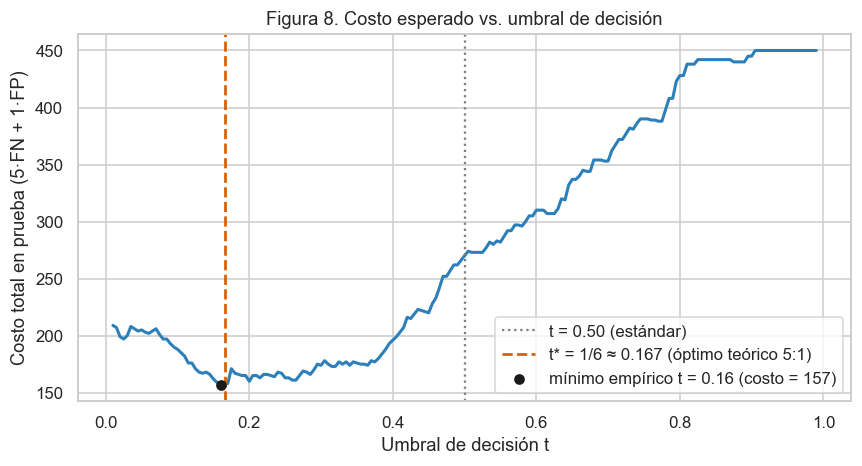

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_08_costo_vs_umbral.png


In [32]:
# Curva de costo empírico vs. umbral (prueba)
# y umbral empírico de costo mínimo

rejilla_t = np.linspace(0.01, 0.99, 197)
costos = np.array([
    evaluar_umbral(t, y_test, p_test)["costo_total"]
    for t in rejilla_t
])

t_emp = float(rejilla_t[np.argmin(costos)])

fig, ax = plt.subplots(figsize=(8, 4.4))

ax.plot(rejilla_t, costos, color="#2c7fb8", lw=2)
ax.axvline(
    0.50,
    color="gray",
    ls=":",
    lw=1.5,
    label="t = 0.50 (estándar)"
)
ax.axvline(
    t_opt_teorico,
    color="#d95f02",
    ls="--",
    lw=1.8,
    label=f"t* = 1/6 ≈ {t_opt_teorico:.3f} (óptimo teórico 5:1)"
)
ax.scatter(
    [t_emp],
    [costos.min()],
    color="k",
    zorder=5,
    label=f"mínimo empírico t = {t_emp:.2f} (costo = {int(costos.min())})"
)

ax.set_xlabel("Umbral de decisión t")
ax.set_ylabel("Costo total en prueba (5·FN + 1·FP)")
ax.set_title("Figura 8. Costo esperado vs. umbral de decisión")
ax.legend()

plt.tight_layout()

# Guardar la figura
ruta_figura_08 = carpeta_figuras / "figura_08_costo_vs_umbral.png"
fig.savefig(
    ruta_figura_08,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {ruta_figura_08}")

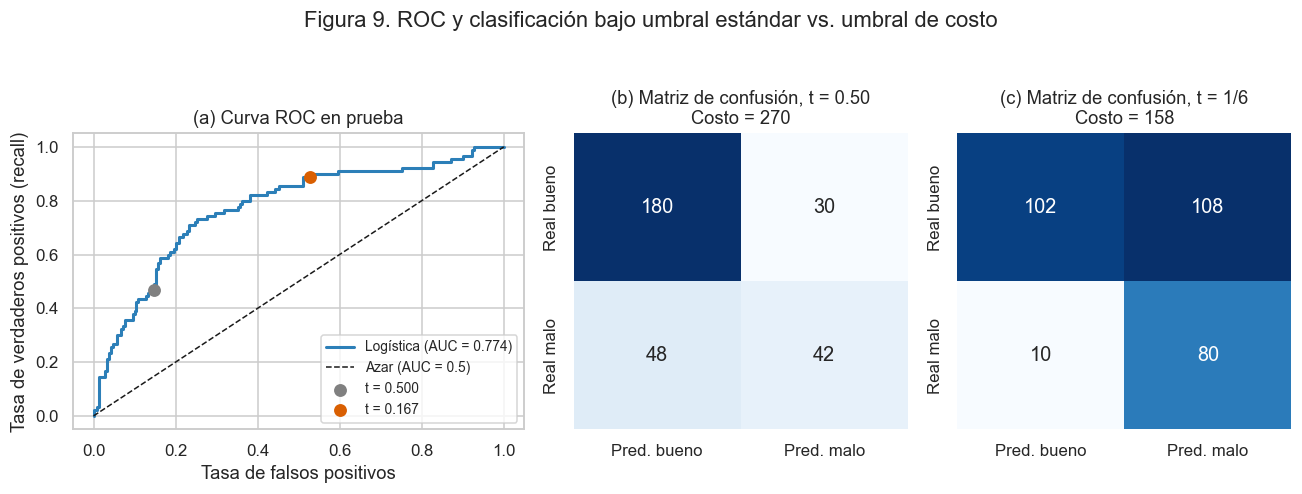

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Estadistica Computacional\MCC002-Final\resultados\figuras\figura_09_roc_y_matrices_confusion.png


In [33]:
# Figura 9. Curva ROC + matrices de confusión bajo ambos umbrales
fig = plt.figure(figsize=(12, 4.3))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax0.plot(
    fpr, tpr,
    color="#2c7fb8",
    lw=2,
    label=f"Logística (AUC = {auc_test:.3f})"
)
ax0.plot([0, 1], [0, 1], "k--", lw=1, label="Azar (AUC = 0.5)")

for t_marca, c in [(0.50, "gray"), (t_opt_teorico, "#d95f02")]:
    i = np.argmin(np.abs(umbrales_roc - t_marca))
    ax0.scatter(
        fpr[i], tpr[i],
        color=c,
        zorder=5,
        s=55,
        label=f"t = {t_marca:.3f}"
    )

ax0.set_xlabel("Tasa de falsos positivos")
ax0.set_ylabel("Tasa de verdaderos positivos (recall)")
ax0.set_title("(a) Curva ROC en prueba")
ax0.legend(loc="lower right", fontsize=9)

for j, (t_m, nombre) in enumerate(
    [(0.50, "t = 0.50"), (t_opt_teorico, "t = 1/6")],
    start=1
):
    axj = fig.add_subplot(gs[j])

    cm = confusion_matrix(
        y_test,
        (p_test >= t_m).astype(int)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        cmap="Blues",
        ax=axj,
        xticklabels=["Pred. bueno", "Pred. malo"],
        yticklabels=["Real bueno", "Real malo"],
        annot_kws={"size": 13}
    )

    costo = C_FN * cm[1, 0] + C_FP * cm[0, 1]
    axj.set_title(
        f"({'bc'[j-1]}) Matriz de confusión, {nombre}\nCosto = {costo}"
    )

fig.suptitle(
    "Figura 9. ROC y clasificación bajo umbral estándar vs. umbral de costo",
    y=1.04
)

plt.tight_layout()

# Guardar la figura
ruta_figura_09 = carpeta_figuras / "figura_09_roc_y_matrices_confusion.png"
fig.savefig(
    ruta_figura_09,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {ruta_figura_09}")

### Conclusión sobre la selección del umbral con costos asimétricos

Al reducir el umbral de decisión de $0.50$ a:

$$
t^{*}=\frac{1}{6}\approx0.167
$$

el modelo adopta una política más conservadora y detecta una mayor proporción de créditos riesgosos.

- El **recall** aumenta de $0.467$ a $0.889$, mientras que los falsos negativos disminuyen de 48 a 10.
- La **precisión** se reduce de $0.583$ a $0.426$ y el **accuracy** disminuye de $0.740$ a $0.607$, debido al aumento de falsos positivos de 30 a 108.
- El **F1-score** mejora de $0.519$ a $0.576$, lo que refleja un mejor equilibrio entre precisión y recall.
- El costo total disminuye de 270 a 158 unidades, equivalente a una reducción aproximada del **41.5 %**.

La reducción de 38 falsos negativos evita un costo de:

$$
38 \times 5 = 190
$$

unidades. Por otro lado, los 78 falsos positivos adicionales generan un costo de 78 unidades. En consecuencia, el ahorro neto es de:

$$
190-78=112
$$

unidades.

Además, el costo mínimo empírico se alcanza cerca de $t=0.16$, con un costo total de 157 unidades. Este resultado es prácticamente igual al obtenido con el umbral teórico $t^{*}=0.167$, cuyo costo es 158, lo que respalda la elección derivada de la matriz de costos.

En conclusión, el umbral estándar de $0.50$ produce una mayor exactitud global, pero resulta menos conveniente desde el punto de vista económico. La selección del umbral debe basarse en el costo relativo de los errores y no únicamente en el `accuracy`.

## 13. Análisis bayesiano de la tasa de mal crédito: modelo Beta-Binomial

### 13.1 Enfoque bayesiano

En las secciones anteriores, la tasa de mal crédito $p$ se trató como un parámetro fijo pero desconocido. A partir de los datos observados:

$$
\hat{p}=\frac{300}{1000}=0.30
$$

se construyeron intervalos de confianza mediante métodos frecuentistas.

El enfoque bayesiano adopta una perspectiva diferente: representa la incertidumbre sobre $p$ mediante una distribución de probabilidad. Esta distribución se actualiza después de observar los datos utilizando el teorema de Bayes:

$$
\pi(p\mid\text{datos})
\propto
L(\text{datos}\mid p)\,\pi(p)
$$

donde:

- $\pi(p)$ es la distribución previa o *prior*.
- $L(\text{datos}\mid p)$ es la verosimilitud aportada por los datos.
- $\pi(p\mid\text{datos})$ es la distribución posterior.

En términos simples, la distribución posterior combina la información disponible antes del análisis con la evidencia observada. El resultado no es únicamente una estimación puntual, sino una distribución completa que representa los valores posibles de la tasa de mal crédito y su grado de incertidumbre.

### 13.2 Modelo Beta-Binomial y distribución posterior

Sea $X$ el número de malos créditos observados en una muestra de $n$ solicitantes. El modelo se define como:

$$
p\sim\mathrm{Beta}(\alpha,\beta)
$$

$$
X\mid p\sim\mathrm{Binomial}(n,p)
$$

En este análisis:

$$
n=1000,
\qquad
x=300
$$

La verosimilitud binomial, considerando únicamente los términos que dependen de $p$, es:

$$
L(p\mid x)
\propto
p^x(1-p)^{n-x}
$$

El prior Beta tiene la forma:

$$
\pi(p)
\propto
p^{\alpha-1}(1-p)^{\beta-1}
$$

Al aplicar el teorema de Bayes:

$$
\pi(p\mid x)
\propto
p^x(1-p)^{n-x}
p^{\alpha-1}(1-p)^{\beta-1}
$$

Agrupando los exponentes:

$$
\pi(p\mid x)
\propto
p^{\alpha+x-1}
(1-p)^{\beta+n-x-1}
$$

Este resultado corresponde al núcleo de otra distribución Beta. Por tanto, la distribución posterior es:

$$
p\mid X=x
\sim
\mathrm{Beta}
\left(
\alpha+x,\,
\beta+n-x
\right)
$$

Esta propiedad se denomina **conjugación**: la distribución Beta es el prior conjugado de la verosimilitud binomial. La actualización consiste en añadir los malos créditos observados al parámetro $\alpha$ y los buenos créditos al parámetro $\beta$.

A partir de la distribución posterior se calcularán los siguientes resúmenes.

#### Media posterior

La media posterior representa el valor esperado de la tasa de mal crédito después de combinar el prior con los datos:

$$
E[p\mid x]
=
\frac{\alpha+x}
{\alpha+\beta+n}
$$

#### Estimación MAP

La estimación de máxima densidad posterior, o MAP, corresponde al valor más probable de $p$ bajo la distribución posterior:

$$
\mathrm{MAP}
=
\frac{\alpha+x-1}
{\alpha+\beta+n-2}
$$

Esta expresión es válida cuando ambos parámetros posteriores son mayores que 1.

#### Intervalo creíble del 95 %

El intervalo creíble se obtiene mediante los cuantiles 2.5 % y 97.5 % de la distribución posterior:

$$
P
\left(
p_{\mathrm{inf}}
\leq p \leq
p_{\mathrm{sup}}
\mid x
\right)
=
0.95
$$

Su interpretación es directa: dados el prior y los datos observados, existe una probabilidad posterior del 95 % de que la tasa de mal crédito se encuentre dentro del intervalo.

### 13.3 Priors y análisis de sensibilidad

Para evaluar cuánto dependen los resultados de la información previa, se comparan tres distribuciones a priori.

#### Prior uniforme: Beta $(1,1)$

$$
p\sim\mathrm{Beta}(1,1)
$$

Este prior asigna la misma densidad a todos los valores de $p$ entre 0 y 1. Representa una posición inicial poco informativa y tendrá una influencia reducida frente a una muestra de 1000 observaciones.

#### Prior de Jeffreys: Beta $(0.5,0.5)$

$$
p\sim\mathrm{Beta}(0.5,0.5)
$$

El prior de Jeffreys es una alternativa no informativa utilizada con frecuencia para proporciones binomiales. Se incluye como control para verificar si una especificación previa diferente modifica de manera relevante los resultados.

#### Prior informativo débil: Beta $(6,18)$

$$
p\sim\mathrm{Beta}(6,18)
$$

La media previa de este prior es:

$$
E[p]
=
\frac{6}{6+18}
=
0.25
$$

Su concentración total es:

$$
\alpha+\beta=24
$$

Este prior representa una expectativa inicial de que la tasa de mal crédito se encuentre cerca del 25 %, pero con un peso reducido frente a las 1000 observaciones disponibles. Por ello, se considera un prior informativo débil.

Para cada prior se compararán:

- la media posterior;
- la estimación MAP;
- el intervalo creíble del 95 %.

El objetivo es determinar si las conclusiones sobre la tasa de mal crédito cambian de manera relevante según el prior utilizado. Si los resultados son similares, se concluirá que la inferencia es robusta frente a la elección de la distribución previa.dejando que los datos dominen.

In [34]:
def posterior_beta_binomial(alpha, beta, x, n):
    "Posterior conjugada cerrada del modelo Beta-Binomial (implementación explícita)."
    a_post, b_post = alpha + x, beta + n - x
    map_ = (a_post - 1) / (a_post + b_post - 2) if (a_post > 1 and b_post > 1) else np.nan
    media = a_post / (a_post + b_post)
    ic = stats.beta.ppf([0.025, 0.975], a_post, b_post)
    return {"a_post": a_post, "b_post": b_post, "MAP": map_,
            "media_post": media, "IC_2.5%": ic[0], "IC_97.5%": ic[1]}

priors = {
    "Beta(1, 1) uniforme": (1.0, 1.0),
    "Beta(0.5, 0.5) Jeffreys": (0.5, 0.5),
    "Beta(6, 18) informativo": (6.0, 18.0),
}

resultados_bayes = pd.DataFrame({
    nombre: posterior_beta_binomial(a, b, x_mal, n) for nombre, (a, b) in priors.items()
}).T

print(f"Datos: x = {x_mal} malos créditos en n = {n} (p_hat frecuentista = {p_hat:.4f})\n")
print(resultados_bayes.round(4))
print(f"\nIC 95% frecuentista (Wilson): ({ic_wilson[0]:.4f}, {ic_wilson[1]:.4f})")

Datos: x = 300 malos créditos en n = 1000 (p_hat frecuentista = 0.3000)

                         a_post  b_post     MAP  media_post  IC_2.5%  IC_97.5%
Beta(1, 1) uniforme       301.0   701.0  0.3000      0.3004   0.2724    0.3291
Beta(0.5, 0.5) Jeffreys   300.5   700.5  0.2998      0.3002   0.2722    0.3289
Beta(6, 18) informativo   306.0   718.0  0.2984      0.2988   0.2712    0.3272

IC 95% frecuentista (Wilson): (0.2724, 0.3291)


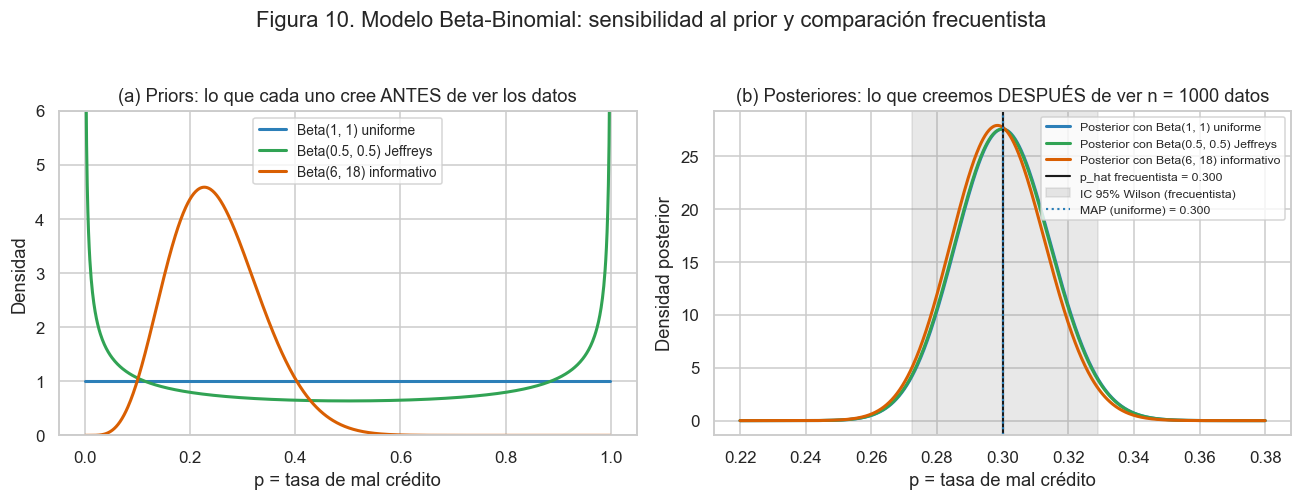

In [35]:
# --- Figura 10. Priors (izquierda) y posteriores (derecha) ---
# Panel (a): los tres priors, para VISUALIZAR qué opina cada uno antes de ver datos.
# Panel (b): las tres posteriores + el IC de Wilson, para ver cuánto importó el prior.

colores_priors = {"Beta(1, 1) uniforme": "#2c7fb8",
                  "Beta(0.5, 0.5) Jeffreys": "#31a354",
                  "Beta(6, 18) informativo": "#d95f02"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) Priors en todo el rango [0, 1]
grid_full = np.linspace(0.001, 0.999, 800)
for nombre, (a, b) in priors.items():
    axes[0].plot(grid_full, stats.beta.pdf(grid_full, a, b),
                 lw=2, color=colores_priors[nombre], label=nombre)
axes[0].set_xlabel("p = tasa de mal crédito"); axes[0].set_ylabel("Densidad")
axes[0].set_title("(a) Priors: lo que cada uno cree ANTES de ver los datos")
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 6)

# (b) Posteriores, con zoom en la zona relevante (0.22 a 0.38)
grid_p = np.linspace(0.22, 0.38, 800)
for nombre, (a, b) in priors.items():
    dens = stats.beta.pdf(grid_p, a + x_mal, b + n - x_mal)  # Beta posterior
    axes[1].plot(grid_p, dens, lw=2, color=colores_priors[nombre],
                 label=f"Posterior con {nombre}")
axes[1].axvline(p_hat, color="k", lw=1.4, label=f"p_hat frecuentista = {p_hat:.3f}")
axes[1].axvspan(ic_wilson[0], ic_wilson[1], color="gray", alpha=0.18,
                label="IC 95% Wilson (frecuentista)")
map_unif = resultados_bayes.loc["Beta(1, 1) uniforme", "MAP"]
axes[1].axvline(map_unif, color="#2c7fb8", ls=":", lw=1.4,
                label=f"MAP (uniforme) = {map_unif:.3f}")
axes[1].set_xlabel("p = tasa de mal crédito"); axes[1].set_ylabel("Densidad posterior")
axes[1].set_title("(b) Posteriores: lo que creemos DESPUÉS de ver n = 1000 datos")
axes[1].legend(fontsize=8)

fig.suptitle("Figura 10. Modelo Beta-Binomial: sensibilidad al prior y comparación frecuentista",
             y=1.03)
plt.tight_layout(); 

fig.savefig(carpeta_figuras / "figura_10_modelo_beta_binomial.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretación de resultados: sensibilidad al prior

Los tres priors analizados producen resultados prácticamente iguales. Las estimaciones MAP se sitúan entre $0.2984$ y $0.3000$, mientras que las medias posteriores se encuentran entre $0.2988$ y $0.3004$. Esto indica que la tasa estimada de malos créditos permanece cercana al valor frecuentista:

$$
\hat{p}=\frac{300}{1000}=0.30.
$$

El prior uniforme genera una posterior $\text{Beta}(301,701)$ y un MAP de $0.3000$, coincidente con la estimación frecuentista. El prior de Jeffreys ofrece resultados casi idénticos, mientras que el prior informativo $\text{Beta}(6,18)$ desplaza ligeramente la estimación hacia su media previa de $0.25$, aunque su influencia es mínima.

Los intervalos creíbles del 95 % también son muy similares. En particular, el intervalo obtenido con el prior uniforme,

$$
(0.2724,\ 0.3291),
$$

coincide numéricamente con el intervalo de confianza de Wilson.

En conjunto, los resultados muestran que la inferencia es **robusta frente a la elección del prior**. Con una muestra de $n=1000$, la información proporcionada por los datos domina claramente las diferencias entre las distribuciones previas.


## 14. Sampler Metropolis–Hastings desde cero para un coeficiente de la regresión logística

### 14.1 Motivación: ¿por qué se necesita MCMC?

En la Sección 13, la conjugación entre la distribución Beta y el modelo binomial permitió obtener la distribución posterior de forma analítica. En la regresión logística bayesiana, esta ventaja desaparece: la verosimilitud Bernoulli-logit no dispone de un prior conjugado que produzca una posterior con forma cerrada.

Como consecuencia, la distribución posterior de los coeficientes,

$$
\pi(\boldsymbol{\beta}\mid\mathbf{y}),
$$

contiene una constante de normalización definida mediante una integral de alta dimensión. En este caso, el vector de parámetros tiene dimensión $d=24$, por lo que el cálculo directo de dicha integral no resulta práctico.

Para resolver este problema se utiliza **MCMC** (*Markov chain Monte Carlo*). En lugar de calcular explícitamente la distribución posterior, se construye una cadena de Markov cuyas observaciones, después de alcanzar la estabilidad, se comportan como muestras de esa posterior.

Metropolis–Hastings permite realizar este muestreo utilizando únicamente la posterior **sin normalizar**, es decir, sin necesidad de conocer su constante de normalización.

La intuición puede entenderse como una exploración aleatoria de la superficie posterior. Desde el estado actual se propone un nuevo punto:

* si el nuevo punto tiene mayor densidad posterior, se acepta;
* si tiene menor densidad, todavía puede aceptarse con una probabilidad proporcional a la disminución de densidad;
* si se rechaza, la cadena permanece en el estado actual.

Al repetir este procedimiento, la cadena visita con mayor frecuencia las regiones de alta probabilidad posterior. Las posiciones registradas permiten aproximar distribuciones marginales, medias, intervalos creíbles y otras cantidades de interés.

### 14.2 Coeficiente de interés y especificación del modelo

El coeficiente seleccionado es:

$$
\beta_{\text{dur}},
$$

correspondiente a la duración del crédito.

Esta variable fue elegida porque mostró una asociación consistente con el riesgo crediticio tanto en las pruebas estadísticas de la Sección 9 como en el modelo de regresión logística de la Sección 11. Además, posee una interpretación práctica directa, ya que puede relacionarse con decisiones sobre plazos y políticas de otorgamiento de crédito.

Sin embargo, para estimar correctamente la distribución marginal de $\beta_{\text{dur}}$, no debe muestrearse este coeficiente de manera aislada. Es necesario aproximar la posterior conjunta de todos los coeficientes:

$$
\boldsymbol{\beta}\in\mathbb{R}^{24},
$$

y posteriormente extraer la componente asociada con la duración.

El modelo bayesiano se define como:

$$
\beta_j \overset{iid}{\sim} \mathcal{N}(0,10^2),
$$

$$
y_i\mid\boldsymbol{\beta}
\sim
\operatorname{Bernoulli}
\left(
\sigma(\mathbf{x}_i^\top\boldsymbol{\beta})
\right),
$$

donde:

$$
\sigma(\eta)=\frac{1}{1+e^{-\eta}}
$$

es la función logística.

El prior $\mathcal{N}(0,10^2)$ es débilmente informativo: restringe valores extremadamente grandes, pero permite que la información de los datos determine principalmente la posterior.

Para $n=700$ observaciones, la log-posterior, omitiendo las constantes que no dependen de $\boldsymbol{\beta}$, es:

$$
\log \pi(\boldsymbol{\beta}\mid\mathbf{y})
=

\sum_{i=1}^{700}
\left[
y_i\eta_i-\log\left(1+e^{\eta_i}\right)
\right]
-

\frac{\lVert\boldsymbol{\beta}\rVert^2}{2\cdot10^2},
$$

con:

$$
\eta_i=\mathbf{x}_i^\top\boldsymbol{\beta}.
$$

Los cálculos se realizan en escala logarítmica para evitar problemas de subdesbordamiento numérico producidos al multiplicar numerosas probabilidades pequeñas.

### 14.3 Algoritmo random-walk Metropolis–Hastings multivariante

El sampler se implementa directamente, sin utilizar librerías especializadas de MCMC.

#### 1. Estado inicial

La cadena comienza en la estimación de máxima verosimilitud:

$$
\boldsymbol{\beta}^{(0)}
=

\widehat{\boldsymbol{\beta}}_{\text{MLE}}.
$$

Este punto de partida se encuentra en una región de alta verosimilitud y, generalmente, también de alta densidad posterior. Esto reduce el tiempo inicial necesario para que la cadena alcance una región representativa de la posterior.

#### 2. Distribución de propuesta

En cada iteración se propone:

$$
\boldsymbol{\beta}'
=

\boldsymbol{\beta}^{(t)}
+
\frac{2.38}{\sqrt{d}}
L\mathbf{z},
$$

donde:

$$
\mathbf{z}\sim\mathcal{N}(\mathbf{0},I),
$$

y la matriz $L$ satisface:

$$
LL^\top
=

\widehat{\Sigma}_{\text{MLE}}.
$$

La matriz $L$ se obtiene mediante la descomposición de Cholesky de la matriz de covarianza estimada del MLE.

Esta propuesta adapta la forma de los desplazamientos a la curvatura del modelo:

* permite pasos mayores en direcciones donde la posterior es más dispersa;
* utiliza pasos menores en direcciones donde la posterior está más concentrada;
* incorpora la correlación existente entre los coeficientes.

El factor:

$$
\frac{2.38}{\sqrt{d}}
$$

corresponde a una regla de escalamiento ampliamente utilizada para propuestas random-walk en problemas multivariantes.

#### 3. Regla de aceptación

Como la distribución de propuesta es simétrica, el término de Hastings se cancela. Primero se calcula la diferencia entre las log-posteriores:

$$
\Delta =
\log \pi(\boldsymbol{\beta}' \mid \mathbf{y})
-
\log \pi(\boldsymbol{\beta}^{(t)} \mid \mathbf{y})
$$

La probabilidad de aceptación es:

$$
\alpha =
\min\left(
1,\,
\exp(\Delta)
\right)
$$

La propuesta se acepta cuando:

$$
\log(u) < \Delta,
\qquad
u \sim \mathrm{Uniforme}(0,1)
$$

Esta comparación en escala logarítmica mejora la estabilidad numérica.

Cuando la propuesta es rechazada, se conserva el estado anterior:

$$
\boldsymbol{\beta}^{(t+1)}
=
\boldsymbol{\beta}^{(t)}
$$

La repetición del estado actual forma parte del algoritmo y debe registrarse como una iteración de la cadena.

#### 4. Diagnóstico del muestreo

Después de generar la cadena, se descarta un número inicial de iteraciones denominado **burn-in**. Este periodo corresponde a la etapa de transición desde el punto inicial hasta una región estable de la posterior.

La calidad del muestreo se evalúa mediante:

* **Gráfico de traza:** permite revisar si la cadena explora de forma estable la distribución posterior y si presenta tendencias o periodos prolongados de inmovilidad.
* **Tasa de aceptación:** indica la proporción de propuestas aceptadas. En problemas multivariantes de dimensión moderada, una tasa cercana al 23 % suele considerarse una referencia útil para propuestas random-walk.
* **Autocorrelación:** muestra el grado de dependencia entre iteraciones consecutivas.
* **Tamaño efectivo de muestra (ESS):** estima cuántas observaciones independientes equivalen a las muestras autocorrelacionadas generadas por la cadena.

Finalmente, se extraen las muestras de la componente $\beta_{\text{dur}}$ para estimar su media posterior, mediana, intervalo creíble y probabilidad de ser positiva. Estas cantidades permitirán evaluar la magnitud y la incertidumbre del efecto de la duración sobre el riesgo de mal crédito.


In [36]:
# --- Preparación: matriz de diseño, MLE y covarianza (para calibrar la propuesta) ---
# Reciclamos del modelo de statsmodels (Sección 0) todo lo que el sampler necesita:
X_mh = modelo_logit.model.exog          # matriz de diseño del train (700 x 24)
y_mh = modelo_logit.model.endog         # vector respuesta (0/1)
nombres = modelo_logit.model.exog_names # nombres de los 24 coeficientes
j_dur = nombres.index("duracion")       # posición del coeficiente de interés

beta_mle = modelo_logit.params.values         # punto de partida de la cadena
Sigma_mle = modelo_logit.cov_params().values  # covarianza estimada del MLE
d_dim = len(beta_mle)                         # dimensión del problema (24)

# Cholesky: L L' = Sigma. Multiplicar L por ruido N(0, I) genera pasos con la
# forma (correlaciones y escalas) de la curvatura de la verosimilitud.
L_chol = np.linalg.cholesky(Sigma_mle)
escala = 2.38 / np.sqrt(d_dim)   # escala óptima de Roberts-Gelman-Gilks
TAU_PRIOR = 10.0                 # desviación estándar del prior N(0, 10^2)

def log_posterior(beta):
    """Log-posterior conjunta (hasta constante aditiva) de la logística bayesiana."""
    eta = X_mh @ beta
    # log-verosimilitud Bernoulli-logit en forma estable:
    # log sigma(eta) = -log(1+e^-eta)  y  log(1-sigma(eta)) = -log(1+e^eta).
    # np.logaddexp(0, eta) = log(1 + e^eta) sin overflow.
    ll = np.sum(y_mh * eta - np.logaddexp(0.0, eta))
    # log-prior N(0, TAU^2) iid en cada coeficiente (sin la constante)
    lp = -0.5 * np.sum((beta / TAU_PRIOR) ** 2)
    return ll + lp

def metropolis_hastings(log_post, beta0, n_iter=40_000, seed=SEED):
    """Random-walk Metropolis-Hastings multivariante, implementado desde cero."""
    rng = np.random.default_rng(seed)
    cadena = np.empty((n_iter, d_dim))
    beta, lp_actual = beta0.copy(), log_post(beta0)
    aceptados = 0
    for t in range(n_iter):
        # Paso 1: proponer un salto aleatorio con la forma de Sigma_MLE
        prop = beta + escala * (L_chol @ rng.standard_normal(d_dim))
        lp_prop = log_post(prop)
        # Paso 2: regla de aceptación de Metropolis (en escala log:
        # aceptar si log(U) < log pi(prop) - log pi(actual), U ~ Unif(0,1))
        if np.log(rng.uniform()) < lp_prop - lp_actual:
            beta, lp_actual = prop, lp_prop
            aceptados += 1
        # Paso 3: guardar el estado (si se rechazó, se repite el actual: así
        # debe ser, la repetición es parte del algoritmo, no un error)
        cadena[t] = beta
    return cadena, aceptados / n_iter

print(f"Dimensión del problema: {d_dim} coeficientes | n_train = {len(y_mh)}")
print(f"Escala de la propuesta: 2.38/sqrt({d_dim}) = {escala:.3f}")
print(f"MLE de beta_dur (referencia): {beta_mle[j_dur]:.5f} "
      f"(EE = {modelo_logit.bse['duracion']:.5f})")

Dimensión del problema: 24 coeficientes | n_train = 700
Escala de la propuesta: 2.38/sqrt(24) = 0.486
MLE de beta_dur (referencia): 0.03825 (EE = 0.01143)


In [37]:
# --- Ejecución del sampler y resúmenes de la posterior ---
N_ITER, BURN_IN = 40_000, 8_000   # 40 mil iteraciones; botamos las primeras 8 mil

cadena, tasa_acept = metropolis_hastings(log_posterior, beta_mle, n_iter=N_ITER)

# Nos quedamos con la componente de la duración, después del burn-in
muestras_dur = cadena[BURN_IN:, j_dur]

# --- Tamaño efectivo de muestra (ESS) ---
# Las muestras MCMC vienen autocorrelacionadas (cada estado depende del
# anterior), así que 32 000 muestras NO valen como 32 000 independientes.
# El ESS estima a cuántas independientes equivalen, usando la suma de
# autocorrelaciones por pares de Geyer (se corta cuando un par se hace negativo).
def ess(x, max_lag=4000):
    x = x - x.mean()
    acov = np.correlate(x, x, mode="full")[len(x)-1:] / len(x)
    rho = acov / acov[0]                 # autocorrelaciones normalizadas
    s, lag = 0.0, 1
    while lag + 1 < min(max_lag, len(rho)):
        par = rho[lag] + rho[lag + 1]    # pares consecutivos (Geyer)
        if par < 0:
            break
        s += par; lag += 2
    return len(x) / (1 + 2 * s)

ic_mh = np.percentile(muestras_dur, [2.5, 97.5])   # intervalo creíble 95 %

print(f"Iteraciones = {N_ITER}, burn-in = {BURN_IN}, retenidas = {N_ITER - BURN_IN}")
print(f"Tasa de aceptación = {tasa_acept:.2%}  (objetivo teórico ~23% para RW-MH)")
print(f"ESS de beta_dur ~ {ess(muestras_dur):.0f}")
print(f"\nPosterior MH de beta_dur : media = {muestras_dur.mean():.5f}, "
      f"sd = {muestras_dur.std(ddof=1):.5f}")
print(f"Intervalo creíble 95%    : ({ic_mh[0]:.5f}, {ic_mh[1]:.5f})")
print(f"MLE (statsmodels)        : {beta_mle[j_dur]:.5f} "
      f"(EE = {modelo_logit.bse['duracion']:.5f})")
print(f"IC 95% frecuentista      : ({modelo_logit.conf_int().loc['duracion', 0]:.5f}, "
      f"{modelo_logit.conf_int().loc['duracion', 1]:.5f})")
print(f"\nOR por mes adicional     : {np.exp(muestras_dur.mean()):.4f} "
      f"(IC creíble del OR: {np.exp(ic_mh[0]):.4f} - {np.exp(ic_mh[1]):.4f})")
print(f"Pr(beta_dur > 0 | datos) = {(muestras_dur > 0).mean():.4f}")

Iteraciones = 40000, burn-in = 8000, retenidas = 32000
Tasa de aceptación = 25.68%  (objetivo teórico ~23% para RW-MH)
ESS de beta_dur ~ 429

Posterior MH de beta_dur : media = 0.04084, sd = 0.01121
Intervalo creíble 95%    : (0.01902, 0.06275)
MLE (statsmodels)        : 0.03825 (EE = 0.01143)
IC 95% frecuentista      : (0.01585, 0.06065)

OR por mes adicional     : 1.0417 (IC creíble del OR: 1.0192 - 1.0648)
Pr(beta_dur > 0 | datos) = 1.0000


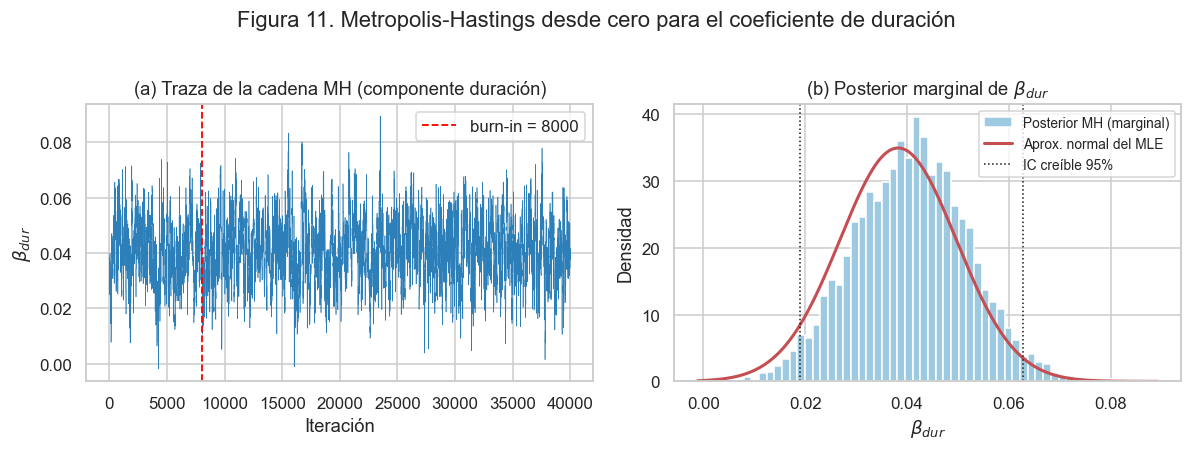

In [38]:
# --- Figura 11. Diagnóstico del sampler ---
# Panel (a): la traza. Queremos ver una "oruga peluda" estable, sin tendencia:
# señal de que la cadena ya está muestreando de la distribución estacionaria.
# Panel (b): la posterior marginal vs. la aproximación normal asintótica del MLE.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(cadena[:, j_dur], lw=0.4, color="#2c7fb8")
axes[0].axvline(BURN_IN, color="red", ls="--", lw=1.2, label=f"burn-in = {BURN_IN}")
axes[0].set_xlabel("Iteración"); axes[0].set_ylabel(r"$\beta_{dur}$")
axes[0].set_title("(a) Traza de la cadena MH (componente duración)")
axes[0].legend()

axes[1].hist(muestras_dur, bins=60, density=True, color="#9ecae1",
             edgecolor="white", label="Posterior MH (marginal)")
gg = np.linspace(muestras_dur.min(), muestras_dur.max(), 400)
axes[1].plot(gg, stats.norm.pdf(gg, beta_mle[j_dur], modelo_logit.bse["duracion"]),
             "r-", lw=2, label="Aprox. normal del MLE")
axes[1].axvline(ic_mh[0], color="k", ls=":", lw=1)
axes[1].axvline(ic_mh[1], color="k", ls=":", lw=1, label="IC creíble 95%")
axes[1].set_xlabel(r"$\beta_{dur}$"); axes[1].set_ylabel("Densidad")
axes[1].set_title("(b) Posterior marginal de $\\beta_{dur}$")
axes[1].legend(fontsize=9)

fig.suptitle("Figura 11. Metropolis-Hastings desde cero para el coeficiente de duración",
             y=1.02)
plt.tight_layout(); 
fig.savefig(carpeta_figuras / "figura_11_metropolis-hastings.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretación de resultados: diagnóstico de la cadena y efecto de la duración

La cadena presenta un comportamiento estable durante las 40 000 iteraciones. La traza no muestra tendencias persistentes ni cambios visibles después del *burn-in*, lo cual es coherente con haber iniciado el muestreo en una región de alta densidad posterior utilizando el MLE como punto inicial.

La tasa de aceptación fue de 25.68 %, valor cercano a la referencia teórica de aproximadamente 23 % para un algoritmo random-walk Metropolis–Hastings multivariante. Después de descartar 8000 iteraciones, se conservaron 32 000 muestras.

El tamaño efectivo de muestra para $\beta_{\text{dur}}$ fue aproximadamente:

$$
ESS \approx 429.
$$

Este resultado refleja la autocorrelación propia del random walk, pero proporciona una cantidad suficiente de información efectiva para estimar la media posterior y los principales cuantiles. Aunque métodos como HMC, MALA o propuestas adaptativas podrían mejorar la eficiencia, el sampler implementado resulta adecuado para los objetivos de este análisis.

La posterior marginal del coeficiente de duración se concentra claramente en valores positivos:

$$
\mathbb{E}[\beta_{\text{dur}} \mid \text{datos}] = 0.04084,
$$

con una desviación estándar posterior de:

$$
SD(\beta_{\text{dur}} \mid \text{datos}) = 0.01121.
$$

El intervalo creíble del 95 % es:

$$
(0.01902,\ 0.06275).
$$

Estos valores son muy cercanos al estimador de máxima verosimilitud y a su intervalo de confianza frecuentista:

$$
\hat{\beta}_{\text{dur}} = 0.03825,
$$

$$
IC_{95\%} = (0.01585,\ 0.06065).
$$

La similitud entre ambos enfoques indica que, con $n=700$ y un prior débil, la información proporcionada por los datos domina la inferencia. También constituye una validación cruzada entre la aproximación frecuentista basada en el MLE y el muestreo bayesiano mediante MCMC.

En términos del *odds ratio*:

$$
\exp(0.04084) = 1.0417.
$$

Por tanto, manteniendo constantes las demás variables, **cada mes adicional de duración incrementa las odds de mal crédito en aproximadamente 4.17 %**.

El efecto acumulado de doce meses adicionales es:

$$
\exp(12 \times 0.04084) \approx 1.63.
$$

Esto representa un incremento aproximado del 63 % en las odds de mal crédito para un año adicional de plazo.

Además:

$$
\Pr(\beta_{\text{dur}} > 0 \mid \text{datos}) = 1.0000,
$$

y el intervalo creíble del *odds ratio* es:

$$
(1.0192,\ 1.0648).
$$

Como todo el intervalo se encuentra por encima de 1, la evidencia posterior respalda una asociación positiva entre una mayor duración del crédito y un mayor riesgo de incumplimiento.

La principal ventaja del enfoque bayesiano es que la cadena proporciona una aproximación a la **distribución posterior completa**, no solamente una estimación puntual y un error estándar. Esto permite calcular directamente probabilidades sobre los parámetros, intervalos creíbles y distribuciones de cantidades derivadas, como *odds ratios* o probabilidades predichas.

## 15. Síntesis integrada de los factores asociados al riesgo crediticio

La evidencia obtenida mediante el análisis exploratorio, las pruebas de hipótesis, la regresión logística y el enfoque bayesiano permite responder la pregunta central del trabajo:

> **¿Qué factores están asociados con una mayor probabilidad de mal riesgo crediticio?**

Los resultados muestran que el riesgo no depende de una sola variable, sino de la combinación entre liquidez disponible, duración y condiciones del crédito, antecedentes financieros y estabilidad económica del solicitante.

| Factor | Evidencia principal | Interpretación |
|---|---|---|
| Estado de la cuenta corriente | Presenta algunos de los *odds ratios* más pronunciados del modelo y un gradiente consistente entre categorías | Un saldo negativo se asocia con mayor riesgo, mientras que una cuenta con saldo favorable se relaciona con menor riesgo |
| Duración del crédito | Diferencia estandarizada de Welch $d \approx 0.48$; OR $\approx 1.04$ por mes; $p \approx 0.001$; $\Pr(\beta_{\text{dur}}>0\mid\text{datos})\approx 1$ | Los créditos de mayor duración presentan un riesgo más elevado, manteniendo constantes las demás variables |
| Monto del crédito | Asociación marginal en Mann–Whitney, con $p \approx 0.006$, pero sin significancia condicional en la regresión logística | El monto parece estar asociado con el riesgo principalmente porque los créditos más altos suelen concederse a plazos más largos |
| Historial crediticio | Algunas categorías presentan *odds ratios* relevantes, considerando la categoría de referencia discutida en la Sección 11 | Un historial limitado o menos favorable incrementa la incertidumbre y puede asociarse con mayor riesgo |
| Ahorros | Las categorías con mayores niveles de ahorro presentan OR menores que 1; por ejemplo, A64 con OR $\approx 0.16$ | Una mayor capacidad de ahorro actúa como protección frente al riesgo de incumplimiento |
| Propósito del crédito | Asociación global significativa: $\chi^2$ con $p \approx 10^{-4}$ y $V \approx 0.18$ | Algunos propósitos, como educación o compra de automóvil nuevo, presentan tasas de mal crédito superiores al promedio |
| Tasa de cuota | OR $\approx 1.23$, con $p \approx 0.04$ | Una mayor proporción del ingreso destinada al pago de cuotas se relaciona con mayor riesgo |
| Vivienda | Vivienda propia con OR $\approx 0.59$ respecto del alquiler | La estabilidad residencial se asocia con una menor probabilidad de mal crédito |

### Coherencia entre los enfoques frecuentista y bayesiano

Los resultados de las Secciones 13 y 14 muestran una elevada consistencia entre ambos enfoques.

Para la tasa global de malos créditos:

$$
\hat{p}_{\text{MLE}}
=
p_{\text{MAP}}
=
0.300
$$

cuando se utiliza el prior uniforme. Asimismo, el intervalo de confianza de Wilson y el intervalo creíble bayesiano son prácticamente idénticos:

$$
(0.272,\ 0.329).
$$

La elección entre los priors uniforme, de Jeffreys e informativo produce cambios mínimos, lo que indica que, con $n=1000$, los datos dominan claramente la información previa.

Para el coeficiente de duración, la posterior obtenida mediante Metropolis–Hastings también es muy cercana a la aproximación frecuentista basada en el MLE:

$$
\mathbb{E}[\beta_{\text{dur}}\mid\text{datos}]
=
0.04084,
$$

frente a:

$$
\hat{\beta}_{\text{dur},\text{MLE}}
=
0.03825.
$$

En ambos análisis, los enfoques frecuentista y bayesiano conducen a resultados numéricos similares, aunque mantienen interpretaciones distintas. Esta convergencia es esperable cuando la muestra es suficientemente grande y el prior ejerce poca influencia.

### Implicancia para la decisión crediticia

La Sección 12 mostró que el umbral de clasificación no debe establecerse automáticamente en $0.50$. Cuando el costo de clasificar como buen crédito a un cliente realmente riesgoso es cinco veces mayor que el costo del error contrario, el umbral teórico es:

$$
t^{*}
=
\frac{1}{5+1}
=
\frac{1}{6}
\approx
0.167.
$$

Al utilizar un umbral cercano a este valor, el costo total observado en el conjunto de prueba disminuye aproximadamente un 41 %, aunque también se reduce la exactitud global.

Este resultado evidencia que la selección del modelo y del umbral debe alinearse con la función de costos del problema. En evaluación crediticia, una mayor *accuracy* no implica necesariamente una mejor decisión si los distintos tipos de error tienen consecuencias económicas diferentes.

## 16. Alcances, limitaciones y validez del análisis

### 16.1 Representatividad y validez externa

El conjunto de datos corresponde a una cartera crediticia alemana histórica, con montos expresados en marcos alemanes y una proporción de malos créditos del 30 %. Esta composición no representa necesariamente la prevalencia observada en una cartera bancaria actual, ya que el dataset contiene una presencia deliberadamente elevada de casos de mal crédito.

Por esta razón, los resultados absolutos, como la tasa global estimada $\hat{p}$ o el intercepto de la regresión logística, **no deben extrapolarse directamente** a otras instituciones, países o periodos. Las asociaciones relativas entre variables y riesgo son más informativas, aunque también deben validarse con datos del contexto donde se pretenda aplicar el modelo.

### 16.2 Interpretación asociativa, no causal

Los *odds ratios* obtenidos representan asociaciones condicionales dentro de datos observacionales. No demuestran que una variable produzca directamente un aumento o una reducción del riesgo.

Además, pueden existir factores de confusión no observados, como ingresos exactos, puntuaciones externas, estabilidad laboral detallada o información crediticia completa. El comportamiento de `historial_credito`, donde una categoría aparentemente crítica puede mostrarse como protectora dependiendo de la categoría de referencia, evidencia el riesgo de interpretar los coeficientes de forma aislada o causal.

### 16.3 Sesgo de selección y *reject inference*

El dataset contiene únicamente solicitudes de crédito que fueron aprobadas. No se dispone de información sobre los solicitantes rechazados ni sobre cuál habría sido su comportamiento si hubieran recibido el préstamo.

En consecuencia, el modelo describe el riesgo dentro de la población históricamente aceptada, pero no necesariamente dentro del conjunto completo de personas que solicitan crédito. Esta limitación se conoce como problema de *reject inference* y puede generar sesgos al trasladar el modelo a nuevas decisiones de aprobación.

### 16.4 Variables sensibles y uso responsable

La variable `estatus_personal_sexo` combina información sobre sexo y estado civil. Su inclusión en un sistema productivo podría generar riesgos de discriminación algorítmica, además de posibles restricciones éticas y normativas.

Por esta razón, la variable fue excluida deliberadamente del modelo predictivo. Esta decisión reduce el riesgo de utilizar atributos sensibles de forma directa, aunque no elimina la posibilidad de que otras variables funcionen como indicadores indirectos o *proxies*. Un uso real requeriría auditorías adicionales de equidad entre grupos.

### 16.5 Limitaciones metodológicas

El análisis presenta algunas limitaciones técnicas que deben considerarse:

- Los residuales del modelo OLS muestran desviaciones leves en las colas, por lo que sus resultados deben interpretarse como una aproximación descriptiva.
- El sampler random-walk Metropolis–Hastings alcanzó un ESS moderado para un problema de 24 dimensiones. Aunque fue suficiente para el coeficiente analizado, su eficiencia podría mejorarse mediante HMC, MALA o propuestas adaptativas.
- La evaluación del costo se realizó sobre un único conjunto de prueba de 300 observaciones. Por ello, el mínimo empírico de la curva puede estar afectado por variabilidad muestral.
- El modelo logístico supone una relación lineal entre los predictores numéricos y el logaritmo de las *odds*. Posibles relaciones no lineales o interacciones podrían no estar completamente representadas.

Estas limitaciones no invalidan los resultados, pero restringen su nivel de generalización y justifican futuras validaciones con remuestreo, validación cruzada y datos externos.

### 16.6 Dependencia de la matriz de costos

El umbral cercano a:

$$
t^{*}=\frac{1}{6}
$$

se deriva de una relación de costos de 5:1, donde clasificar erróneamente a un cliente riesgoso como buen crédito tiene un costo cinco veces mayor que rechazar a un cliente de bajo riesgo.

Esta relación corresponde al planteamiento del dataset y no debe asumirse automáticamente en una aplicación real. En producción, los costos deberían estimarse utilizando pérdidas económicas observadas, como la pérdida dado el incumplimiento (LGD), la exposición al incumplimiento (EAD), los costos de oportunidad y los gastos de cobranza.

Por tanto, el umbral de decisión no es una propiedad fija del modelo. Debe ajustarse al contexto económico de la institución y revisarse periódicamente ante cambios en la cartera, la prevalencia del incumplimiento o las condiciones del mercado.

## 17. Síntesis final y recomendaciones

### 17.1 Principales hallazgos

1. La proporción global de malos créditos fue:

$$
\hat{p}=0.300,
$$

con un intervalo de confianza de Wilson del 95 % igual a:

$$
(0.272,\ 0.329).
$$

Este resultado coincide prácticamente con el intervalo creíble bayesiano. Además, las estimaciones obtenidas con los priors uniforme, de Jeffreys e informativo fueron muy similares, lo que evidencia una inferencia robusta frente a la elección del prior con $n=1000$.

2. El propósito, la duración y el monto del crédito mostraron asociaciones marginales con la clase de riesgo. Sin embargo, al controlar simultáneamente por las demás variables, el monto perdió significancia estadística, mientras que la duración mantuvo un efecto positivo y consistente. Por ello, **la duración es el principal factor numérico asociado con el riesgo crediticio**.

El análisis bayesiano confirmó este resultado:

$$
\Pr(\beta_{\text{dur}}>0\mid\text{datos})\approx 1.
$$

3. La regresión logística alcanzó un AUC cercano a $0.77$ tanto en el conjunto de prueba como en validación cruzada, sin evidencia importante de sobreajuste. Los factores con mayor relevancia condicional fueron el estado de la cuenta corriente, la duración, el historial crediticio, los ahorros, la vivienda y la proporción del ingreso destinada al pago de cuotas.

4. Bajo una relación de costos de $5:1$, el umbral de decisión teórico fue:

$$
t^{*}=\frac{1}{6}\approx 0.17.
$$

Su aplicación redujo el costo total observado en prueba de 270 a 158, equivalente a una disminución aproximada del 41 % respecto del umbral convencional de $0.50$. Esta mejora se obtuvo a cambio de una reducción en la exactitud global.

Por tanto, la *accuracy* no debe utilizarse como único criterio de evaluación: en este problema, la métrica principal debe reflejar el costo desigual de los errores de clasificación.

5. El sampler Metropolis–Hastings multivariante implementado desde cero produjo una posterior para $\beta_{\text{dur}}$ muy cercana a la inferencia frecuentista basada en el MLE. La tasa de aceptación, la traza y el tamaño efectivo de muestra fueron compatibles con un desempeño adecuado para el objetivo del análisis.

En conjunto, los enfoques frecuentista y bayesiano condujeron a la misma interpretación sustantiva: **los créditos de mayor duración presentan un mayor riesgo de incumplimiento, manteniendo constantes las demás características del solicitante y del préstamo**.

### 17.2 Recomendaciones

- **Definir el umbral mediante costos reales.** El punto de corte no debe fijarse automáticamente en $0.50$. Debe calcularse a partir de la matriz de costos de la institución y revisarse cuando cambien la prevalencia del incumplimiento, las condiciones económicas o la composición de la cartera.

- **Priorizar el control de los plazos.** La duración mostró una asociación más estable con el riesgo que el monto del crédito. Por ello, las políticas de otorgamiento deberían considerar límites de plazo, ajustes de tasa, garantías adicionales o revisiones más estrictas para operaciones de larga duración.

- **Recalibrar antes de una aplicación productiva.** El modelo debe entrenarse y validarse con información propia, reciente y representativa de la población objetivo. No se recomienda trasladar directamente el intercepto, la tasa global de incumplimiento ni el umbral estimado en este dataset.

- **Incorporar pérdidas económicas observadas.** La matriz de costos debería estimarse utilizando componentes como la exposición al incumplimiento (EAD), la pérdida dado el incumplimiento (LGD), la probabilidad de recuperación, los costos de cobranza y el costo de oportunidad de rechazar clientes solventes.

- **Evaluar selección y equidad.** Una implementación real debería considerar el problema de *reject inference*, auditar posibles diferencias de desempeño entre grupos y revisar si variables aparentemente neutrales actúan como indicadores indirectos de atributos protegidos.

- **Extender la modelización estadística.** Como trabajos posteriores, se recomienda comparar la regresión logística con modelos de árboles y métodos de ensamble utilizando la misma función de costo. También sería conveniente explorar regresión logística bayesiana jerárquica, propuestas adaptativas y algoritmos como HMC o NUTS para mejorar la eficiencia del muestreo.